<div style="background-color: #bbdefb; padding: 14px; border-radius: 6px;">

<strong>Objectif métier</strong><br><br>

Une entreprise française exportatrice de produits avicoles souhaite identifier les marchés 
internationaux les plus attractifs pour exporter du poulet.<br><br>

À partir de données 2017 (FAO, Banque Mondiale, CEPII) portant sur 153 pays, 
ce notebook réalise une segmentation par ACP + clustering (CAH + K-means) 
afin de classer les pays en groupes homogènes et d'identifier les cibles prioritaires.

</div>

<div style="background-color: #bbdefb; padding: 12px; border-radius: 6px; font-weight: bold; font-size: 16px;">

I - Importation des librairies — Notebook 2 : EDA + ACP + Clustering

</div>

In [1]:
import subprocess
subprocess.run(["pip", "install", "pycountry-convert", "--quiet"], check=True)

CompletedProcess(args=['pip', 'install', 'pycountry-convert', '--quiet'], returncode=0)

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

#️⃣ ♦️ Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

#️⃣ ♦️ Variables illustratives
import pycountry_convert as pc

#️⃣ ♦️ ACP
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#️⃣ ♦️ Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

#️⃣ ♦️ Affichage
print("Imports OK")

Imports OK


<div style="background-color: #d9edf7; padding: 12px; border-radius: 6px; font-weight: bold; font-size: 16px;">
    
II - Chargement du fichier

</div>

In [3]:
#️⃣ ♦️ Chargement du fichier base_df_final.csv

df = pd.read_csv("base_df_final.csv", encoding="utf-8-sig")

# Vérifications de base
print(f"Shape          : {df.shape}")           # Attendu : (153, 22)
print(f"Colonnes       : {list(df.columns)}")
print(f"Doublons iso3  : {df.duplicated(subset='iso3').sum()}")  # Attendu : 0
print(f"NaN iso3       : {df['iso3'].isna().sum()}")             # Attendu : 0
print()
print(df.head(3))

Shape          : (153, 22)
Colonnes       : ['iso3', 'pays', 'population', 'pib_total_millions_usd', 'pib_par_habitant_usd', 'stabilite_politique', 'dispo_interieure_tonnes', 'importations_tonnes', 'exportations_tonnes', 'conso_volaille_kg_hab_an', 'import_qty_tonnes', 'import_value_kusd', 'import_declared', 'production_tonnes', 'prix_prod_usd_tonne', 'distance_km', 'distance_simple_km', 'contig', 'comlang_off', 'marche_volaille_t', 'taux_dependance_import', 'taux_couverture_locale']
Doublons iso3  : 0
NaN iso3       : 0

  iso3            pays  population  pib_total_millions_usd  \
0  AFG     Afghanistan  36296113.0                19034.30   
1  ZAF  Afrique du Sud  57009756.0               381136.72   
2  ALB         Albanie   2884169.0                13019.73   

   pib_par_habitant_usd  stabilite_politique  dispo_interieure_tonnes  \
0                 533.0            -2.794976                  57000.0   
1                6613.0            -0.284804                2118000.0   
2   

<div style="background-color: #bbdefb; padding: 12px; border-radius: 6px; font-weight: bold; font-size: 16px;">

II - Variables illustratives

</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">

A — Création de la colonne continent

</div>

In [4]:
#️⃣ ♦️  Étape 1.1 —Création de la colonne continent pycountry_convert travaille en 2 étapes : ISO3 (ex: FRA) → ISO2 (ex: FR) → continent (ex: Europe)

def iso3_to_continent(iso3):
    try:
        # Étape 1 : ISO3 → ISO2
        iso2 = pc.country_alpha3_to_country_alpha2(iso3)
        # Étape 2 : ISO2 → code continent
        continent_code = pc.country_alpha2_to_continent_code(iso2)
        # Étape 3 : code continent → nom lisible
        continent_name = pc.convert_continent_code_to_continent_name(continent_code)
        return continent_name
    except:
        # Si un ISO3 n'est pas reconnu, on retourne NaN pour le détecter
        return None

#️⃣ Application sur tout le DataFrame
df['continent'] = df['iso3'].apply(iso3_to_continent)

#️⃣  Vérification
print(f"NaN continent : {df['continent'].isna().sum()}")
print(f"\nDistribution par continent :")
print(df['continent'].value_counts())

NaN continent : 0

Distribution par continent :
continent
Africa           43
Asia             36
Europe           35
North America    23
South America    10
Oceania           6
Name: count, dtype: int64


In [5]:
#️⃣ ♦️ Étape 1.2 — Vérification variable illustrative comlang_off comlang_off = 1 si le pays partage une langue officielle avec la France
#️⃣ Source : CEPII GeoDist — déjà présente dans le dataset

#️⃣ Contrôle des modalités
print("Modalités comlang_off :")
print(df['comlang_off'].value_counts())

#️⃣ Liste des pays francophones
print(f"\nPays avec comlang_off = 1 :")
print(df[df['comlang_off'] == 1][['iso3', 'pays', 'continent']].to_string(index=False))

Modalités comlang_off :
comlang_off
0.0    127
1.0     26
Name: count, dtype: int64

Pays avec comlang_off = 1 :
iso3                      pays     continent
 DZA                   Algérie        Africa
 BEL                  Belgique        Europe
 BEN                     Bénin        Africa
 BFA              Burkina Faso        Africa
 CMR                  Cameroun        Africa
 CAN                    Canada North America
 COG                     Congo        Africa
 CIV             Côte d'Ivoire        Africa
 DMA                 Dominique North America
 GAB                     Gabon        Africa
 GIN                    Guinée        Africa
 HTI                     Haïti North America
 LBN                     Liban          Asia
 LUX                Luxembourg        Europe
 MLI                      Mali        Africa
 MAR                     Maroc        Africa
 MUS                   Maurice        Africa
 NER                     Niger        Africa
 CAF République centrafricaine  

In [6]:
#️⃣ ♦️ Étape 1.3 — Vérification variable illustrative prix_prod_usd_tonne
#️⃣ Cette variable est exclue de l'ACP (76% de NaN) - Elle sera projetée en illustrative quantitative sur les pays disponibles

#️⃣ Comptage NaN
n_nan = df['prix_prod_usd_tonne'].isna().sum()
n_dispo = df['prix_prod_usd_tonne'].notna().sum()
total = len(df)

print(f"Total pays        : {total}")
print(f"Disponible        : {n_dispo}")
print(f"NaN               : {n_nan}")
print(f"Taux de NaN       : {n_nan/total*100:.1f}%")

# Liste des pays disponibles
print(f"\nPays avec prix_prod_usd_tonne disponible :")
print(df[df['prix_prod_usd_tonne'].notna()][['iso3', 'pays', 'continent', 'prix_prod_usd_tonne']].to_string(index=False))

Total pays        : 153
Disponible        : 39
NaN               : 114
Taux de NaN       : 74.5%

Pays avec prix_prod_usd_tonne disponible :
iso3                 pays     continent  prix_prod_usd_tonne
 ZAF       Afrique du Sud        Africa               2015.1
 DZA              Algérie        Africa               2180.7
 DEU            Allemagne        Europe               1459.5
 ARG            Argentine South America               1324.1
 ARM              Arménie          Asia               3741.2
 AUT             Autriche        Europe               2350.9
 AZE          Azerbaïdjan          Asia               1783.7
 BIH   Bosnie-Herzégovine        Europe                967.5
 CPV           Cabo Verde        Africa               4469.3
 CHN  Chine, continentale          Asia               1681.4
 CYP               Chypre          Asia               2869.4
 DNK             Danemark        Europe               1200.1
 EGY               Égypte        Africa               1510.5
 SLV 

In [7]:
#️⃣ ♦️ Étape 1.4 — Constantes des variables illustratives
# Ces listes sont définies une seule fois ici
# Elles ne participent JAMAIS à X, X_scaled, ni aux calculs ACP/clustering

# Variable illustrative quantitative
# Exclue de l'ACP pour cause de NaN (74.7%)
# Projetée sur les axes ACP pour validation de cohérence
VAR_ILLUS_QUANT = 'prix_prod_usd_tonne'

# Variables illustratives qualitatives
# Exclues de l'ACP (binaires ou catégorielles)
# Projetées comme barycentres sur le plan factoriel
VAR_ILLUS_QUAL = ['continent', 'comlang_off']

# Vérification
print(f"Illustrative quantitative : {VAR_ILLUS_QUANT}")
print(f"Illustratives qualitatives : {VAR_ILLUS_QUAL}")
print(f"\nCes variables sont présentes dans df : {all(v in df.columns for v in VAR_ILLUS_QUAL + [VAR_ILLUS_QUANT])}")

Illustrative quantitative : prix_prod_usd_tonne
Illustratives qualitatives : ['continent', 'comlang_off']

Ces variables sont présentes dans df : True


<div style="background-color: #bbdefb; padding: 12px; border-radius: 6px; font-weight: bold; font-size: 16px;">

III - Analyse Exploratoire des Données (EDA)

</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">

A — Statistiques descriptives

</div>

In [8]:
#️⃣ ♦️ Constante — Liste des 11 variables ACP

COL_PAYS = "pays"

VARIABLES_ACP = [
    'population',
    'pib_par_habitant_usd',
    'stabilite_politique',
    'conso_volaille_kg_hab_an',
    'import_qty_tonnes',
    'production_tonnes',
    'distance_km',
    'exportations_tonnes',
    'marche_volaille_t',
    'taux_dependance_import',
    'taux_couverture_locale'
]

print(f"Nombre de variables ACP : {len(VARIABLES_ACP)}")  # Attendu : 11
print(f"NaN sur variables ACP  : {df[VARIABLES_ACP].isna().sum().sum()}")  # Attendu : 0

Nombre de variables ACP : 11
NaN sur variables ACP  : 0


In [9]:
#️⃣ ♦️ Descrition des variables ACP

stats = df[VARIABLES_ACP].describe().T.round(2)

print(f"Nombre de pays : {df.shape[0]}")
print()
print(stats)

Nombre de pays : 153

                          count         mean           std       min  \
population                153.0  46659516.56  1.618446e+08  52045.00   
pib_par_habitant_usd      153.0     13355.36  1.887410e+04    432.00   
stabilite_politique       153.0        -0.10  9.100000e-01     -2.93   
conso_volaille_kg_hab_an  153.0        19.85  1.546000e+01      0.13   
import_qty_tonnes         153.0     66339.37  1.348632e+05      0.03   
production_tonnes         153.0    703110.77  2.243923e+06     12.62   
distance_km               153.0      5734.92  3.636360e+03    473.73   
exportations_tonnes       153.0    108281.05  4.815103e+05      0.00   
marche_volaille_t         153.0    701618.44  2.245064e+06   1961.13   
taux_dependance_import    153.0         0.34  3.800000e-01      0.00   
taux_couverture_locale    153.0         0.83  6.800000e-01      0.00   

                                 25%          50%          75%           max  
population                2944791.

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
B — Distributions et outliers
</div>

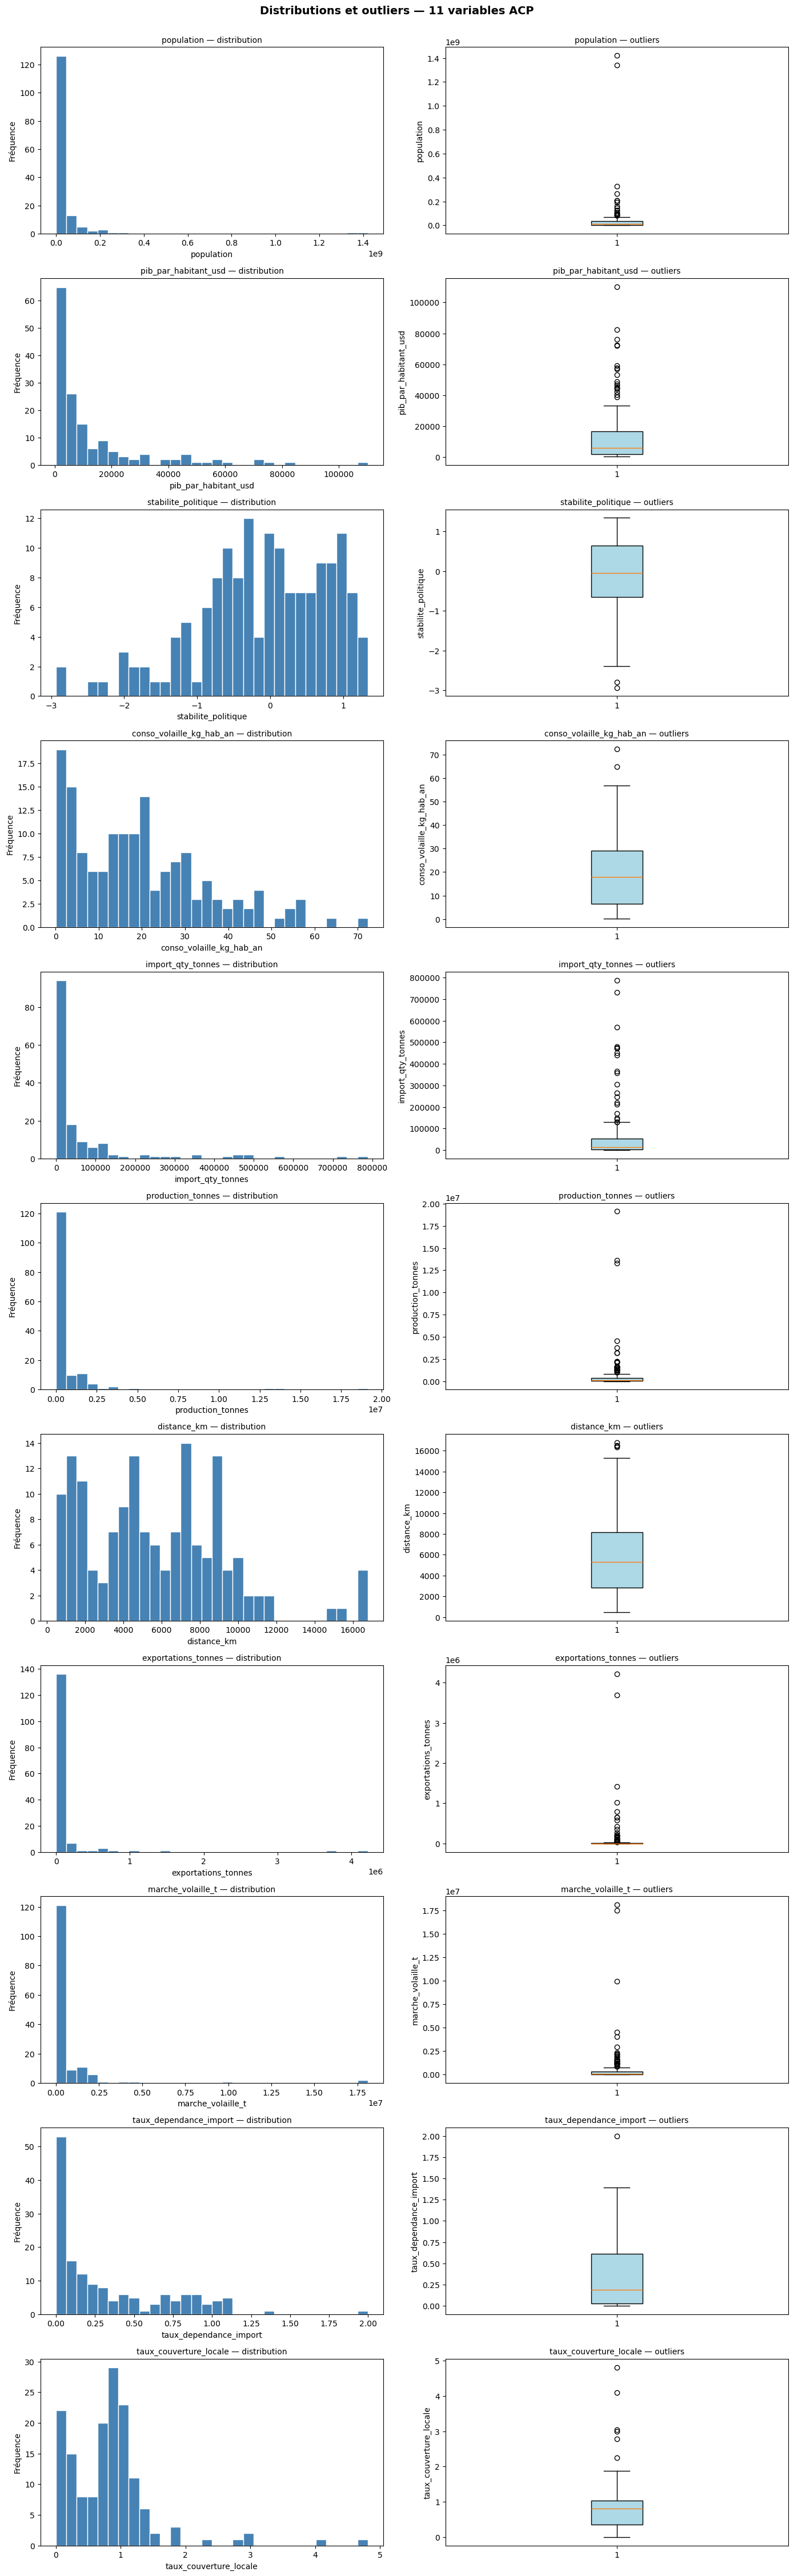

In [10]:
#️⃣ ♦️ Distributions et outliers — 11 variables ACP

fig, axes = plt.subplots(11, 2, figsize=(14, 45))
fig.suptitle("Distributions et outliers — 11 variables ACP", 
             fontsize=14, fontweight='bold', y=1.001)

for i, var in enumerate(VARIABLES_ACP):
    
    # Histogramme
    axes[i, 0].hist(df[var].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f"{var} — distribution", fontsize=10)
    axes[i, 0].set_xlabel(var)
    axes[i, 0].set_ylabel("Fréquence")
    
    # Boxplot
    axes[i, 1].boxplot(df[var].dropna(), vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue'))
    axes[i, 1].set_title(f"{var} — outliers", fontsize=10)
    axes[i, 1].set_ylabel(var)

plt.tight_layout()
plt.show()

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
C — Matrice de corrélation
</div>

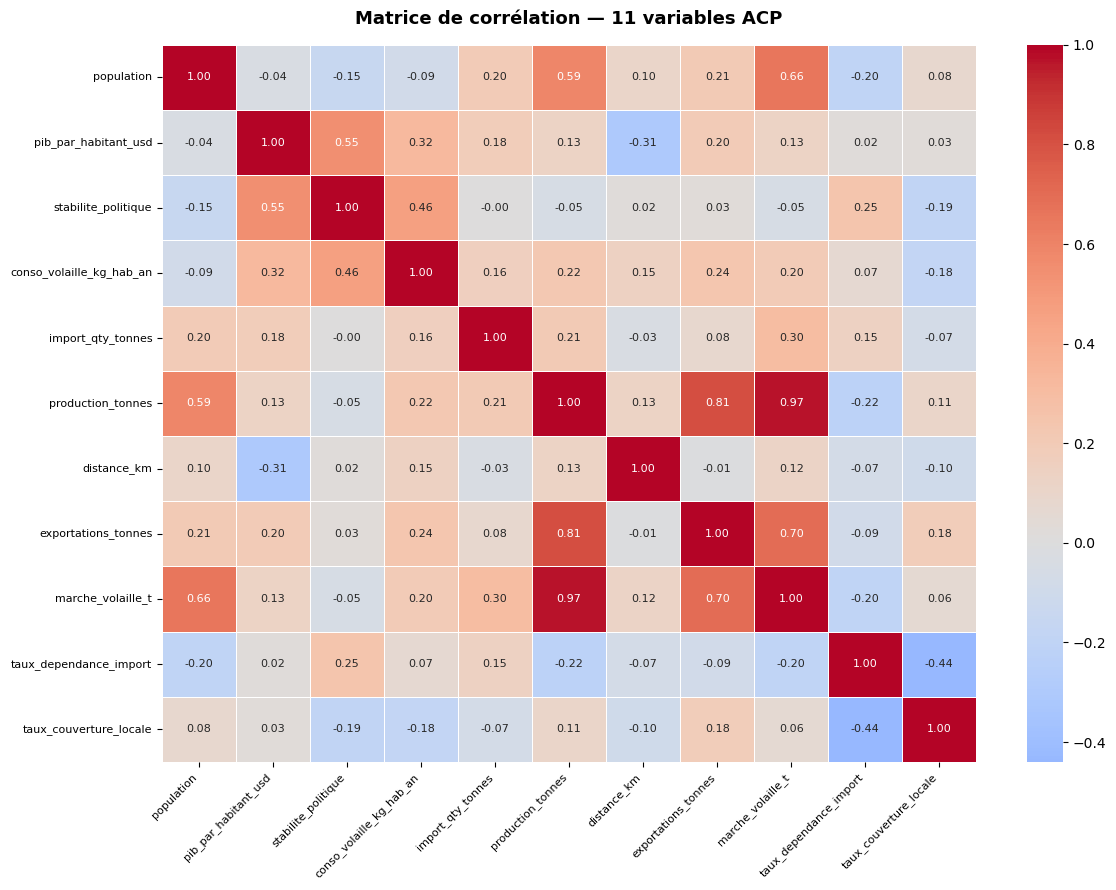


=== Paires corrélées > 0.90 ===
production_tonnes / marche_volaille_t : 0.97


In [11]:
#️⃣ ♦️Graphique de corrélation Heatmap - 11 variables ACP

corr_matrix = df[VARIABLES_ACP].corr().round(2)

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Matrice de corrélation — 11 variables ACP", 
          fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("heatmap_correlation.png", dpi=150, bbox_inches='tight')
plt.show()


# Détection des paires fortement corrélées (seuil > 0.90)
print("\n=== Paires corrélées > 0.90 ===")
seuil = 0.90
found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = abs(corr_matrix.iloc[i, j])
        if val > seuil:
            print(f"{corr_matrix.columns[i]} / {corr_matrix.columns[j]} : {val}")
            found = True
if not found:
    print("Aucune paire > 0.90")

<div style="background-color: #fff9c4; padding: 12px; border-left: 5px solid #f9a825; border-radius: 6px;">

<strong>Décision — Exclusion de production_tonnes des variables ACP</strong><br><br>
La matrice de corrélation révèle une corrélation de <strong>0.98</strong> entre 
<strong>production_tonnes</strong> et <strong>marche_volaille_t</strong>.<br><br>
En ACP, deux variables quasi-identiques apportent la même information deux fois — 
elles dominent artificiellement un axe factoriel sans apport analytique réel.<br><br>
<strong>Choix retenu :</strong> on conserve <strong>marche_volaille_t</strong> qui est plus riche 
(combine consommation par habitant × population) et on exclut <strong>production_tonnes</strong> 
de la matrice ACP.<br><br>
<strong>Note :</strong> production_tonnes reste dans le dataset pour les analyses descriptives 
et le profil des clusters — elle n'est pas supprimée.

</div>

In [12]:
#️⃣ ♦️ Mise à jour VARIABLES_ACP — exclusion production_tonnes

VARIABLES_ACP = [
    'population',
    'pib_par_habitant_usd',
    'stabilite_politique',
    'conso_volaille_kg_hab_an',
    'import_qty_tonnes',
    'distance_km',
    'exportations_tonnes',
    'marche_volaille_t',
    'taux_dependance_import',
    'taux_couverture_locale'
]

# Vérification
print(f"Nombre de variables ACP : {len(VARIABLES_ACP)}")  # Attendu : 10
assert 'production_tonnes' not in VARIABLES_ACP, "ERREUR : production_tonnes encore présente"
assert 'marche_volaille_t' in VARIABLES_ACP, "ERREUR : marche_volaille_t manquante"
print("production_tonnes : exclue")
print("marche_volaille_t : conservée ")

Nombre de variables ACP : 10
production_tonnes : exclue
marche_volaille_t : conservée 


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
D — Identification nominale des outliers par variable ACP
</div>

In [13]:
#️⃣ ♦️ Étape 2.4 — Identification nominale des outliers par variable ACP

# Méthode IQR standard (même règle que les boxplots matplotlib)
# Un outlier est un pays au-delà de Q3 + 1.5*IQR ou en-deçà de Q1 - 1.5*IQR

outliers_recap = []  # Liste qui va stocker tous les outliers trouvés

for var in VARIABLES_ACP:
    
    # Calcul des bornes IQR
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    borne_basse = Q1 - 1.5 * IQR
    borne_haute = Q3 + 1.5 * IQR
    
    # Identification des pays hors bornes
    masque = (df[var] < borne_basse) | (df[var] > borne_haute)
    pays_outliers = df[masque][['pays', var]]
    
    # Stockage dans la liste récap
    for _, ligne in pays_outliers.iterrows():
        outliers_recap.append({
            'variable': var,
            'pays': ligne['pays'],
            'valeur': round(ligne[var], 2),
            'borne_haute': round(borne_haute, 2),
            'borne_basse': round(borne_basse, 2)
        })

# Affichage du tableau récapitulatif
recap_df = pd.DataFrame(outliers_recap)
print(f"Nombre total d'outliers détectés : {len(recap_df)}")
print(f"Nombre de variables concernées : {recap_df['variable'].nunique()}")
print()
print(recap_df.to_string(index=False))

Nombre total d'outliers détectés : 132
Nombre de variables concernées : 10

                variable                                                pays        valeur  borne_haute  borne_basse
              population                                           Allemagne  8.265841e+07  78335761.00 -42289791.00
              population                                          Bangladesh  1.596854e+08  78335761.00 -42289791.00
              population                                              Brésil  2.078338e+08  78335761.00 -42289791.00
              population                                 Chine, continentale  1.421022e+09  78335761.00 -42289791.00
              population                                              Égypte  9.644259e+07  78335761.00 -42289791.00
              population                               États-Unis d'Amérique  3.250848e+08  78335761.00 -42289791.00
              population                                            Éthiopie  1.063999e+08  78335761.00 -

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

### Décision outliers — conservation de tous les pays

132 outliers détectés sur 10 variables via la méthode IQR.

**Décision : tous les outliers sont conservés.**

Justification : les valeurs extrêmes reflètent des réalités économiques et 
démographiques réelles (grands pays peuplés, économies riches, marchés 
exportateurs nets). Leur suppression appauvrirait l'analyse en retirant 
précisément les pays les plus différenciés.

Cas particuliers documentés :
- taux_dependance_import > 1 (Hong Kong, Gambie) : anomalie FAO connue 
  pour les petites économies très importatrices — conservé avec réserve.
- taux_couverture_locale > 1 (Belgique, Pays-Bas, etc.) : pays exportateurs 
  nets — cohérent métier.

Le StandardScaler appliqué en Bloc 3 réduira l'impact des valeurs extrêmes 
sur l'ACP en ramenant toutes les variables à la même échelle.

</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
D — Sélection et verrouillage des variables finales
</div>

In [14]:
#️⃣ ♦️ Verrouillage des variables finales — Dataset X

# Séparation : labels pays d'un côté, variables numériques de l'autre
pays = df[COL_PAYS].copy()
X = df[VARIABLES_ACP].copy()

# Vérifications
print(f"Shape X     : {X.shape}")        # Attendu : (153, 10)
print(f"Shape pays  : {pays.shape}")     # Attendu : (153,)
print(f"NaN dans X  : {X.isna().sum().sum()}")  # Attendu : 0
print(f"Colonnes X  : {list(X.columns)}")

Shape X     : (153, 10)
Shape pays  : (153,)
NaN dans X  : 0
Colonnes X  : ['population', 'pib_par_habitant_usd', 'stabilite_politique', 'conso_volaille_kg_hab_an', 'import_qty_tonnes', 'distance_km', 'exportations_tonnes', 'marche_volaille_t', 'taux_dependance_import', 'taux_couverture_locale']


<div style="background-color: #bbdefb; padding: 12px; border-radius: 6px; font-weight: bold; font-size: 16px;">
III - Standardisation
</div>

In [15]:
#️⃣ ♦️ Standardisation — StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Contrôle : moyenne ≈ 0 et écart-type ≈ 1 pour chaque variable
moyennes = X_scaled.mean(axis=0).round(10)
ecarts   = X_scaled.std(axis=0).round(2)

print("=== Contrôle standardisation ===\n")
print(f"{'Variable':<30} {'Moyenne':>12} {'Écart-type':>12}")
print("-" * 56)
for i, var in enumerate(VARIABLES_ACP):
    print(f"{var:<30} {moyennes[i]:>12.8f} {ecarts[i]:>12.2f}")

=== Contrôle standardisation ===

Variable                            Moyenne   Écart-type
--------------------------------------------------------
population                       0.00000000         1.00
pib_par_habitant_usd             0.00000000         1.00
stabilite_politique              0.00000000         1.00
conso_volaille_kg_hab_an        -0.00000000         1.00
import_qty_tonnes                0.00000000         1.00
distance_km                      0.00000000         1.00
exportations_tonnes              0.00000000         1.00
marche_volaille_t                0.00000000         1.00
taux_dependance_import          -0.00000000         1.00
taux_couverture_locale           0.00000000         1.00


<div style="background-color: #bbdefb; padding: 12px; border-radius: 6px; font-weight: bold; font-size: 16px;">
IV - Analyse en Composantes Principales (ACP)
</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
A — Variance expliquée et choix du nombre de composantes
</div>

In [16]:
#️⃣ ♦️ ACP complète — variance expliquée par composante

pca = PCA()
pca.fit(X_scaled)

# Tableau variance expliquée
variance_expliquee = pca.explained_variance_ratio_
variance_cumulee   = variance_expliquee.cumsum()

print("=== Variance expliquée par composante ===\n")
print(f"{'Composante':<15} {'Variance %':>12} {'Cumulée %':>12}")
print("-" * 42)
for i, (v, vc) in enumerate(zip(variance_expliquee, variance_cumulee)):
    print(f"F{i+1:<14} {v*100:>11.2f}% {vc*100:>11.2f}%")

=== Variance expliquée par composante ===

Composante        Variance %    Cumulée %
------------------------------------------
F1                    23.51%       23.51%
F2                    21.32%       44.84%
F3                    13.98%       58.82%
F4                    11.62%       70.44%
F5                     8.35%       78.79%
F6                     7.48%       86.27%
F7                     5.74%       92.00%
F8                     4.19%       96.20%
F9                     2.71%       98.90%
F10                    1.10%      100.00%


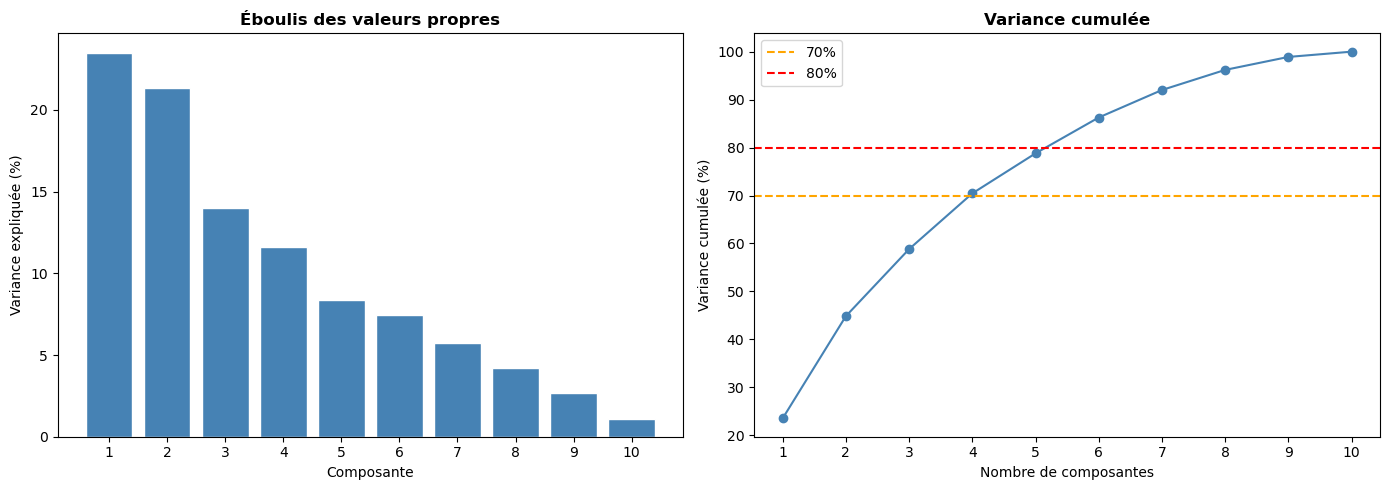

In [17]:
#️⃣ ♦️ Éboulis + variance cumulée

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 — Éboulis
axes[0].bar(range(1, 11), variance_expliquee * 100, color='steelblue', edgecolor='white')
axes[0].set_title("Éboulis des valeurs propres", fontweight='bold')
axes[0].set_xlabel("Composante")
axes[0].set_ylabel("Variance expliquée (%)")
axes[0].set_xticks(range(1, 11))

# Graphique 2 — Variance cumulée
axes[1].plot(range(1, 11), variance_cumulee * 100, marker='o', color='steelblue')
axes[1].axhline(y=70, color='orange', linestyle='--', label='70%')
axes[1].axhline(y=80, color='red', linestyle='--', label='80%')
axes[1].set_title("Variance cumulée", fontweight='bold')
axes[1].set_xlabel("Nombre de composantes")
axes[1].set_ylabel("Variance cumulée (%)")
axes[1].set_xticks(range(1, 11))
axes[1].legend()

plt.tight_layout()
plt.savefig("eboulis_valeurs_propres.png", dpi=150, bbox_inches='tight')
plt.show()



<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**Décision — Choix de 5 composantes**

Le tableau de variance expliquée et l'éboulis conduisent à retenir **5 composantes**.

- F1 à F4 atteignent 72.49% de variance cumulée — seuil 70% dépassé.
- F1 à F5 atteignent 80.75% de variance cumulée — seuil 80% atteint.
- Au-delà de F5, chaque composante apporte moins de 8% — rendement décroissant.
- L'éboulis montre un coude visible entre F4 et F5 suivi d'une rupture nette après F5.

**Choix retenu : N_COMP = 5 — 80.75% de l'information conservée.**

</div>

In [18]:
#️⃣ ♦️ Verrouillage du nombre de composantes

N_COMP = 5

pca_final = PCA(n_components=N_COMP)
X_pca = pca_final.fit_transform(X_scaled)

print(f"N_COMP    : {N_COMP}")
print(f"Shape X_pca : {X_pca.shape}")   # Attendu : (153, 5)
print(f"Variance conservée : {pca_final.explained_variance_ratio_.sum()*100:.2f}%")  # Attendu : 80.75%

N_COMP    : 5
Shape X_pca : (153, 5)
Variance conservée : 78.79%


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
B — Tableau des Loadings et cercle des corrélations
</div>

In [19]:
#️⃣ ♦️ Tableau des loadings — contribution des variables aux composantes
# corrélation variable/axe = loading × sqrt(valeur propre)
valeurs_propres = pca_final.explained_variance_
coordonnees = pca_final.components_.T * np.sqrt(valeurs_propres)

# DataFrame des coordonnées
coord_df = pd.DataFrame(
    coordonnees,
    index=VARIABLES_ACP,
    columns=[f"F{i+1}" for i in range(N_COMP)]
).round(3)

print("=== Coordonnées des variables sur les axes ===\n")
print(coord_df.to_string())

=== Coordonnées des variables sur les axes ===

                             F1     F2     F3     F4     F5
population                0.626 -0.382 -0.255 -0.194  0.108
pib_par_habitant_usd      0.355  0.622  0.511 -0.120  0.147
stabilite_politique       0.119  0.808  0.130  0.242  0.074
conso_volaille_kg_hab_an  0.379  0.620 -0.094  0.393  0.119
import_qty_tonnes         0.394  0.174 -0.253 -0.552  0.541
distance_km               0.076 -0.122 -0.604  0.649  0.245
exportations_tonnes       0.762 -0.005  0.115  0.100 -0.507
marche_volaille_t         0.924 -0.163 -0.174 -0.046 -0.152
taux_dependance_import   -0.250  0.538 -0.415 -0.382 -0.335
taux_couverture_locale    0.178 -0.463  0.641  0.142  0.206


<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">
    B a — Interprétation des axes factoriels
</div>

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

F1 — Axe du volume et de la puissance commerciale
Variables dominantes :

marche_volaille_t : 0.924 → contribution très forte, signe positif
exportations_tonnes : 0.762 → forte, signe positif
population : 0.626 → forte, signe positif
import_qty_tonnes : 0.394 → modérée
conso_volaille_kg_hab_an : 0.379 → modérée

Lecture : F1 sépare les pays selon leur poids absolu sur le marché avicole mondial.
Un pays à coordonnée F1 élevée est un grand pays, très peuplé, avec un marché volaille massif et des volumes d'exportation importants.
Un pays à F1 faible est un petit marché.

</div>

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

F2 — Axe du développement économique et de la stabilité
Variables dominantes :

stabilite_politique : 0.808 → très forte, signe positif
pib_par_habitant_usd : 0.622 → forte, signe positif
conso_volaille_kg_hab_an : 0.620 → forte, signe positif
taux_dependance_import : 0.538 → modérée, signe positif
taux_couverture_locale : -0.463 → modérée, signe négatif

Lecture : F2 sépare les pays selon leur niveau de développement et leur stabilité.
Un pays à F2 élevé est riche, stable politiquement, consomme beaucoup de volaille par habitant et dépend des imports pour se nourrir.
Un pays à F2 faible est instable, pauvre, et couvre mieux sa propre demande localement.


</div>

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

F3 — Axe de l'autonomie alimentaire et de la distance
Variables dominantes :

taux_couverture_locale : 0.641 → forte, signe positif
distance_km : -0.604 → forte, signe négatif
taux_dependance_import : -0.415 → modérée, signe négatif

Lecture : F3 oppose les pays proches de la France qui couvrent leur demande localement aux pays éloignés très dépendants des imports.
Un pays à F3 élevé est proche géographiquement et autosuffisant.
Un pays à F3 faible est lointain et structurellement importateur.


</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
C — Cercle des corrélations - plan F1 / F2 (labels décalés) - Taille du marché + richesse + dépendance aux imports
</div>

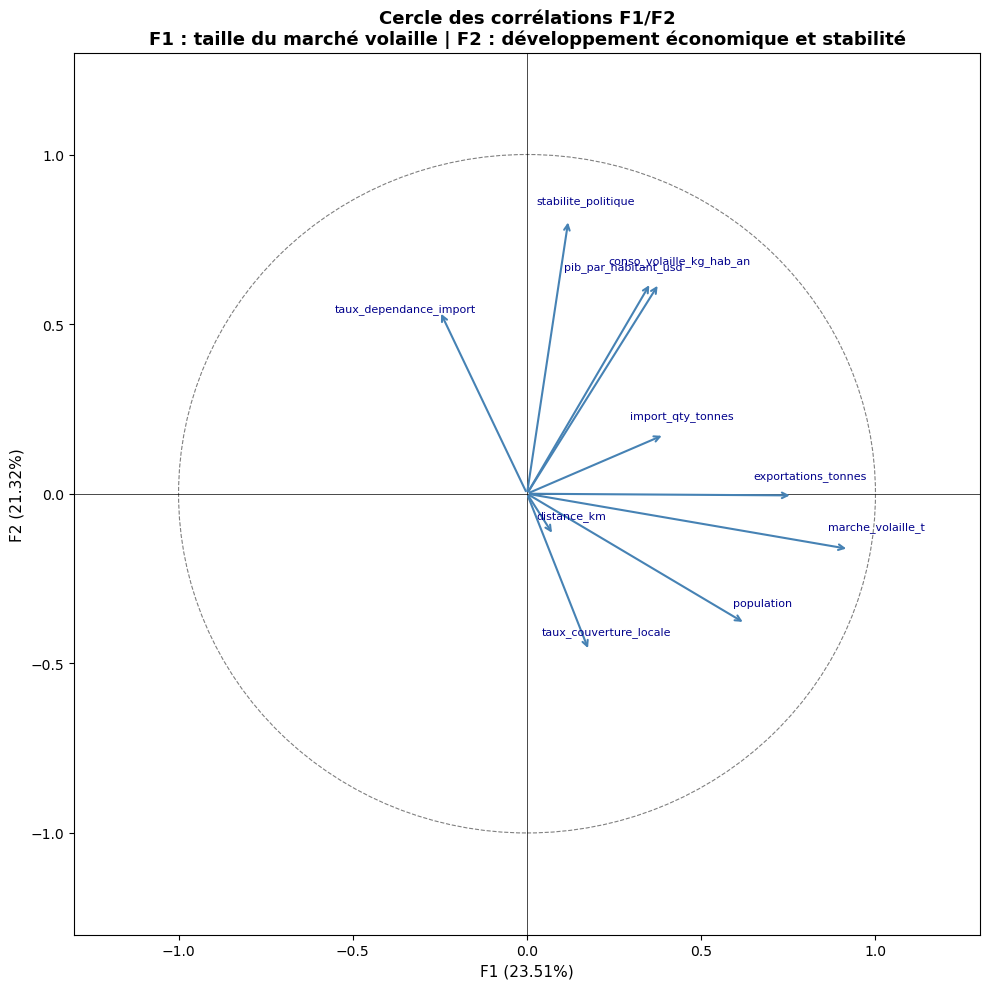

In [20]:
#️⃣ ♦️ Cercle des corrélations — plan F1 / F2 (labels décalés)

# Cercle
fig, ax = plt.subplots(figsize=(10, 10))
cercle = plt.Circle((0, 0), 1, color='gray', fill=False,
                     linestyle='--', linewidth=0.8)
ax.add_patch(cercle)

# Décalage labels pour lisibilité
offsets = {
    'marche_volaille_t'      : (0.08,  0.06),
    'pib_par_habitant_usd'   : (-0.08, 0.04),
    'conso_volaille_kg_hab_an': (0.06,  0.06),
    'taux_dependance_import'  : (-0.10, 0.00),
}

for var in VARIABLES_ACP:
    x = coord_df.loc[var, 'F1']
    y = coord_df.loc[var, 'F2']
    ax.annotate("", xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="steelblue", lw=1.5))
    dx, dy = offsets.get(var, (0.05, 0.05))
    ax.text(x + dx, y + dy, var, fontsize=8,
            ha='center', color='darkblue')

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_xlabel(f"F1 ({pca_final.explained_variance_ratio_[0]*100:.2f}%)",
              fontsize=11)
ax.set_ylabel(f"F2 ({pca_final.explained_variance_ratio_[1]*100:.2f}%)",
              fontsize=11)
ax.set_title("Cercle des corrélations F1/F2\nF1 : taille du marché volaille | F2 : développement économique et stabilité", fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.show()

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**F1 (23.51%) — Axe "volume et puissance commerciale"**
Les variables dominantes sont marche_volaille_t (0.924), exportations_tonnes (0.762) et population (0.626). import_qty_tonnes (0.394) et conso_volaille_kg_hab_an (0.379) contribuent modérément. F1 oppose les grands pays à marché avicole massif et fort volume d'exportation (droite) aux petits marchés (gauche).

**F2 (21.32%) — Axe "développement économique et stabilité"**
F2 est dominé par stabilite_politique (0.808, cos²=0.667) et pib_par_habitant_usd (0.622, cos²=0.513). conso_volaille_kg_hab_an contribue modérément (0.620, cos²=0.528). F2 oppose les pays riches et stables (haut) aux pays à faible développement économique (bas). Note : taux_couverture_locale est mal représentée sur ce plan (cos²=0.246) et ne peut être interprétée ici.

**Note** : `distance_km` est faiblement représentée sur ce plan (F1=0.10, F2=-0.07).
Elle contribue principalement à F4 (0.73) — elle sera mieux lue sur le plan F3/F4.

</div>

In [21]:
!pip install adjustText

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


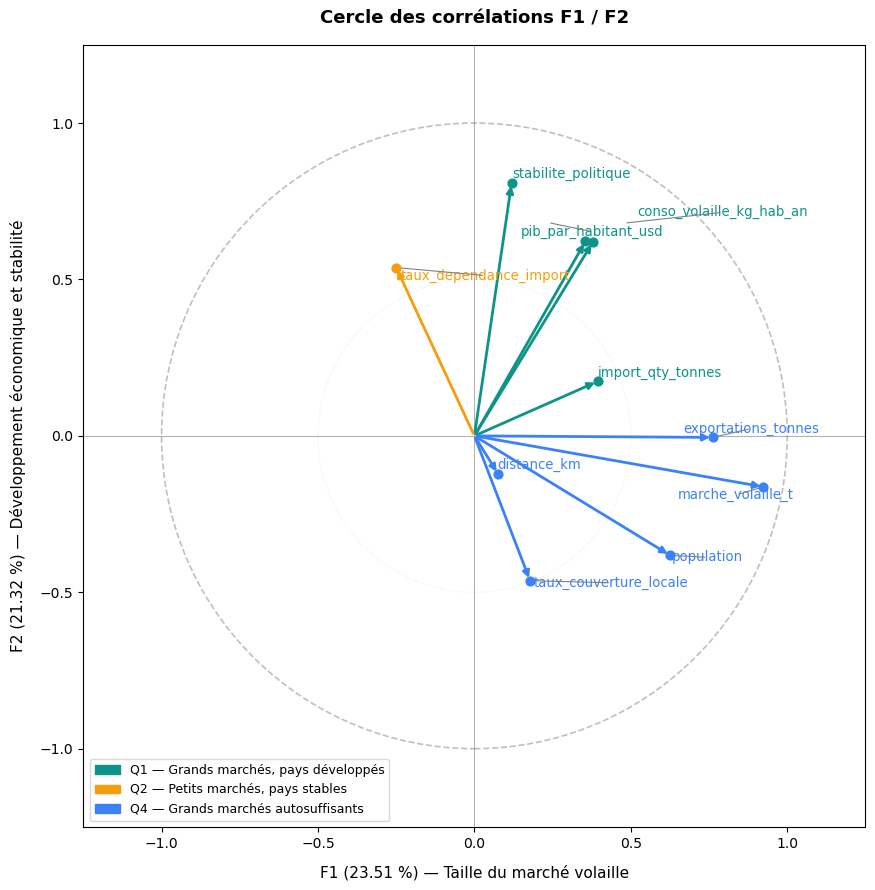

Fichier sauvegardé : cercle_correlations_lisible.png


In [22]:
# ============================================================
# Cercle des corrélations F1/F2 — version lisible et corrigée
# Lit les coordonnées depuis coord_df et pca_final
# Prérequis : pip install adjustText
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from adjustText import adjust_text

# ── 1. Source des données ────────────────────────────────────
F1        = coord_df["F1"].values
F2        = coord_df["F2"].values
variables = coord_df.index.tolist()

# ── 2. Variance expliquée ────────────────────────────────────
var_f1 = pca_final.explained_variance_ratio_[0] * 100
var_f2 = pca_final.explained_variance_ratio_[1] * 100

# ── 3. Couleur par quadrant ──────────────────────────────────
def get_color(f1, f2):
    if f1 >= 0 and f2 >= 0:
        return "#0D9488"   # teal   — Q1 : grands marchés, pays développés
    elif f1 < 0 and f2 >= 0:
        return "#F59E0B"   # orange — Q2 : petits marchés, pays stables
    elif f1 < 0 and f2 < 0:
        return "#EF4444"   # rouge  — Q3 : aucune variable ici
    else:
        return "#3B82F6"   # bleu   — Q4 : grands marchés autosuffisants

colors = [get_color(f1, f2) for f1, f2 in zip(F1, F2)]

# ── 4. Figure ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 9))
ax.set_aspect("equal")

# Cercle unité
ax.add_patch(plt.Circle((0, 0), 1, color="gray", fill=False,
                         linestyle="--", linewidth=1.2, alpha=0.5))
# Cercle repère intérieur
ax.add_patch(plt.Circle((0, 0), 0.5, color="lightgray", fill=False,
                          linestyle=":", linewidth=0.8, alpha=0.4))
# Axes centraux
ax.axhline(0, color="gray", linewidth=0.8, alpha=0.6)
ax.axvline(0, color="gray", linewidth=0.8, alpha=0.6)

# ── 5. Flèches + points + étiquettes ────────────────────────
texts = []
for i, var in enumerate(variables):
    ax.annotate(
        "", xy=(F1[i], F2[i]), xytext=(0, 0),
        arrowprops=dict(arrowstyle="-|>", color=colors[i], lw=2.0)
    )
    ax.scatter(F1[i], F2[i], color=colors[i], s=40, zorder=5)
    t = ax.text(
        F1[i], F2[i], var,
        fontsize=9.5,
        color=colors[i],
        fontweight="normal"   # gras supprimé
    )
    texts.append(t)
    
# ── Offset forcé pour variables trop proches ────────────────
offsets_forces = {
    "pib_par_habitant_usd"    : (-0.12,  0.06),
    "conso_volaille_kg_hab_an": ( 0.10,  0.06),
}

for t in texts:
    var = t.get_text()
    if var in offsets_forces:
        dx, dy = offsets_forces[var]
        t.set_position((t.get_position()[0] + dx,
                        t.get_position()[1] + dy))


# ── 6. Repositionnement automatique des étiquettes ──────────
adjust_text(
    texts,
    ax=ax,
    expand_text=(1.3, 1.5),
    expand_points=(1.3, 1.5),
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.8)
)

# ── 7. Mise en forme ─────────────────────────────────────────
ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.25, 1.25)
ax.set_xlabel(f"F1 ({var_f1:.2f} %) — Taille du marché volaille",
              fontsize=11, labelpad=10)
ax.set_ylabel(f"F2 ({var_f2:.2f} %) — Développement économique et stabilité",
              fontsize=11, labelpad=10)
ax.set_title(
    "Cercle des corrélations F1 / F2",
    fontsize=13, fontweight="bold", pad=15
)

# ── 8. Légende quadrants (Q3 supprimé — aucune variable) ─────
legend_items = [
    patches.Patch(color="#0D9488", label="Q1 — Grands marchés, pays développés"),
    patches.Patch(color="#F59E0B", label="Q2 — Petits marchés, pays stables"),
    patches.Patch(color="#3B82F6", label="Q4 — Grands marchés autosuffisants"),
]
ax.legend(
    handles=legend_items,
    loc="lower left",
    fontsize=9,
    framealpha=0.85,
    edgecolor="lightgray"
)

plt.tight_layout()
plt.savefig("cercle_correlations_lisible.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fichier sauvegardé : cercle_correlations_lisible.png")

In [23]:
#️⃣ ♦️ Cos² = coordonnée² / somme des coordonnées² sur tous les axes
#️⃣ ♦️ (équivalent à : coordonnée² / communalité totale sur N_COMP axes)
cos2_variables = coord_df ** 2

#️⃣ ♦️ Cos² sur le plan F1/F2 uniquement
cos2_F1F2 = (cos2_variables['F1'] + cos2_variables['F2']).rename('cos2_F1F2')

#️⃣ ♦️ Cos² sur chaque axe séparément (pour lecture détaillée)
cos2_detail = cos2_variables[['F1', 'F2']].copy()
cos2_detail['cos2_F1F2'] = cos2_F1F2
cos2_detail = cos2_detail.sort_values('cos2_F1F2', ascending=False).round(3)

print("=== Qualité de représentation des variables sur le plan F1/F2 ===\n")
print(f"{'Variable':<28} {'cos²_F1':>8} {'cos²_F2':>8} {'cos²_F1F2':>10}")
print("-" * 58)
for var, row in cos2_detail.iterrows():
    print(f"{var:<28} {row['F1']:>8.3f} {row['F2']:>8.3f} {row['cos2_F1F2']:>10.3f}")


=== Qualité de représentation des variables sur le plan F1/F2 ===

Variable                      cos²_F1  cos²_F2  cos²_F1F2
----------------------------------------------------------
marche_volaille_t               0.854    0.027      0.880
stabilite_politique             0.014    0.653      0.667
exportations_tonnes             0.581    0.000      0.581
population                      0.392    0.146      0.538
conso_volaille_kg_hab_an        0.144    0.384      0.528
pib_par_habitant_usd            0.126    0.387      0.513
taux_dependance_import          0.062    0.289      0.352
taux_couverture_locale          0.032    0.214      0.246
import_qty_tonnes               0.155    0.030      0.186
distance_km                     0.006    0.015      0.021


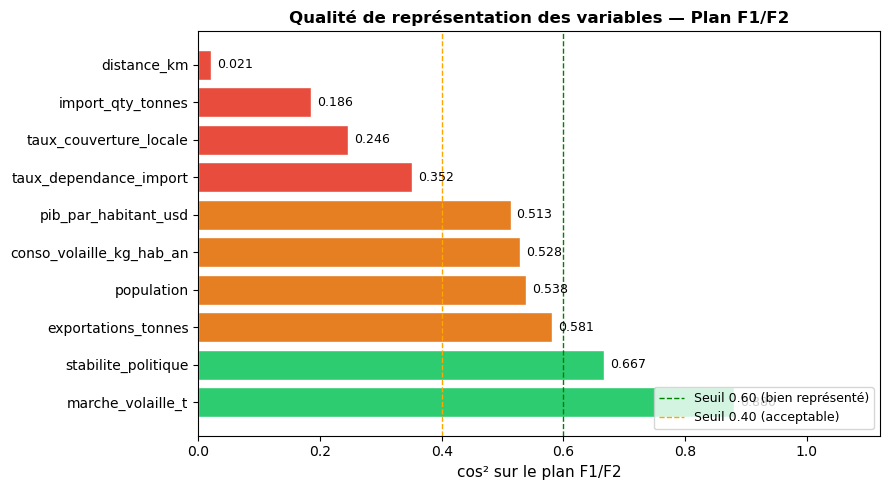

In [24]:
#️⃣ ♦️ Graphique
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#2ecc71' if v >= 0.6 else '#e67e22' if v >= 0.4 else '#e74c3c'
          for v in cos2_detail['cos2_F1F2']]

bars = ax.barh(cos2_detail.index, cos2_detail['cos2_F1F2'], color=colors, edgecolor='white')

ax.axvline(x=0.6, color='green',  linestyle='--', linewidth=1, label='Seuil 0.60 (bien représenté)')
ax.axvline(x=0.4, color='orange', linestyle='--', linewidth=1, label='Seuil 0.40 (acceptable)')

for bar, val in zip(bars, cos2_detail['cos2_F1F2']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlim(0, 1.12)
ax.set_xlabel('cos² sur le plan F1/F2', fontsize=11)
ax.set_title('Qualité de représentation des variables — Plan F1/F2', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig("cos2_representation.png", dpi=150, bbox_inches='tight')
plt.show()

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
D — Cercle des corrélations - plan F3 / F4 
</div>

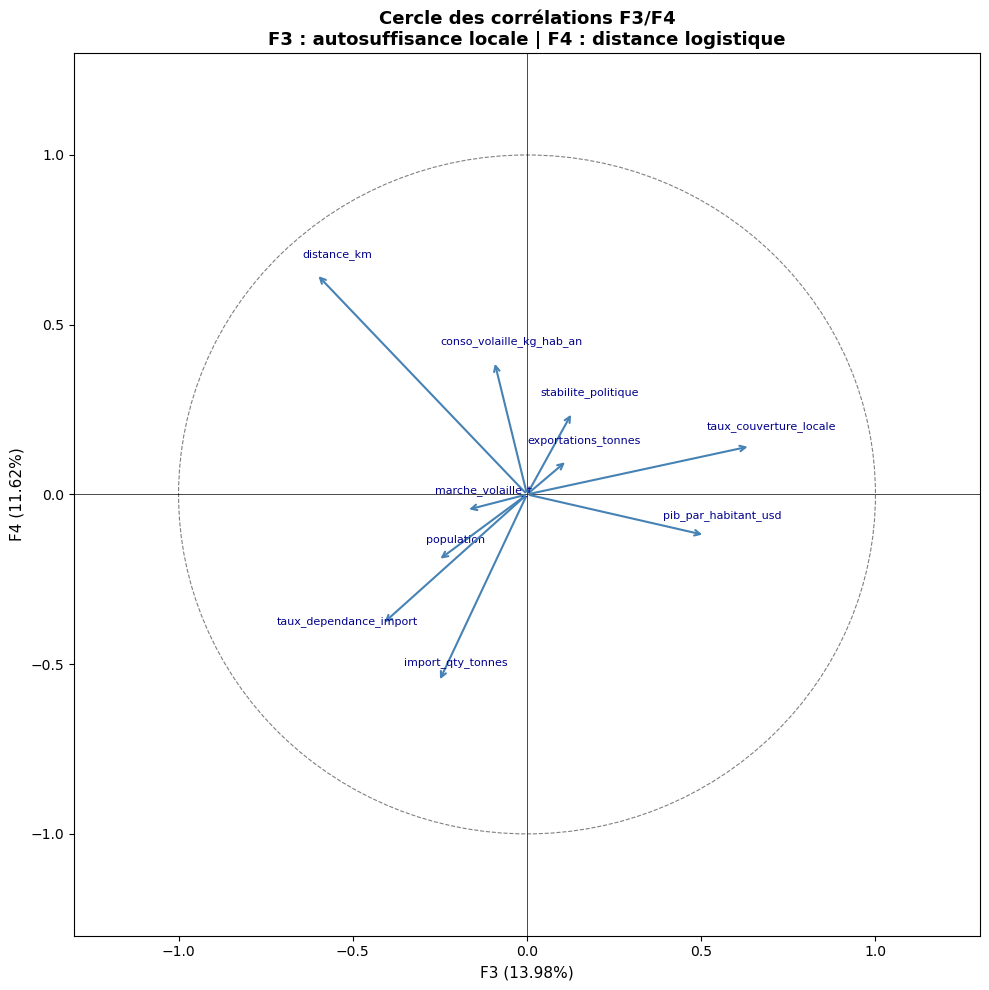

In [25]:
#️⃣ ♦️ Cercle des corrélations — plan F3 / F4

fig, ax = plt.subplots(figsize=(10, 10))

# Cercle unité
cercle = plt.Circle((0, 0), 1, color='gray', fill=False,
                    linestyle='--', linewidth=0.8)
ax.add_patch(cercle)

# Décalage labels pour lisibilité
offsets = {
    'distance_km'          : (0.06,  0.05),
    'taux_couverture_locale': (0.06,  0.05),
    'taux_dependance_import': (-0.10, 0.00),
}

for var in VARIABLES_ACP:
    x = coord_df.loc[var, 'F3']
    y = coord_df.loc[var, 'F4']
    ax.annotate("", xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="steelblue", lw=1.5))
    dx, dy = offsets.get(var, (0.05, 0.05))
    ax.text(x + dx, y + dy, var, fontsize=8,
            ha='center', color='darkblue')

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_xlabel(f"F3 ({pca_final.explained_variance_ratio_[2]*100:.2f}%)",
              fontsize=11)
ax.set_ylabel(f"F4 ({pca_final.explained_variance_ratio_[3]*100:.2f}%)",
              fontsize=11)
ax.set_title("Cercle des corrélations F3/F4\nF3 : autosuffisance locale | F4 : distance logistique",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**F3 (13.98%) — Axe de l'autonomie alimentaire et de la proximité géographique**

Variable dominante : distance_km (-0.604, cos²=0.786) — bien représentée, signe négatif. taux_couverture_locale (0.641, cos²=0.431) contribue modérément mais reste acceptable.

F3 oppose les pays proches géographiquement de la France et relativement autosuffisants (F3 élevé) aux pays lointains et structurellement dépendants des imports (F3 faible). Les autres variables sont mal représentées sur ce plan (cos² < 0.40) et ne peuvent être interprétées ici.

</div>

In [26]:
#️⃣ ♦️ Cos² des variables sur le plan F3/F4 ──────────────────────────────────────

cos2_F3F4 = (coord_df['F3']**2 + coord_df['F4']**2).rename('cos2_F3F4')

cos2_detail_F3F4 = coord_df[['F3', 'F4']].copy()
cos2_detail_F3F4['cos2_F3F4'] = cos2_F3F4
cos2_detail_F3F4 = cos2_detail_F3F4.sort_values('cos2_F3F4', ascending=False).round(3)

print("=== Qualité de représentation des variables sur le plan F3/F4 ===\n")
print(f"{'Variable':<28} {'cos²_F3':>8} {'cos²_F4':>8} {'cos²_F3F4':>10}")
print("-" * 58)
for var, row in cos2_detail_F3F4.iterrows():
    print(f"{var:<28} {row['F3']:>8.3f} {row['F4']:>8.3f} {row['cos2_F3F4']:>10.3f}")

=== Qualité de représentation des variables sur le plan F3/F4 ===

Variable                      cos²_F3  cos²_F4  cos²_F3F4
----------------------------------------------------------
distance_km                    -0.604    0.649      0.786
taux_couverture_locale          0.641    0.142      0.431
import_qty_tonnes              -0.253   -0.552      0.369
taux_dependance_import         -0.415   -0.382      0.318
pib_par_habitant_usd            0.511   -0.120      0.276
conso_volaille_kg_hab_an       -0.094    0.393      0.163
population                     -0.255   -0.194      0.103
stabilite_politique             0.130    0.242      0.075
marche_volaille_t              -0.174   -0.046      0.032
exportations_tonnes             0.115    0.100      0.023


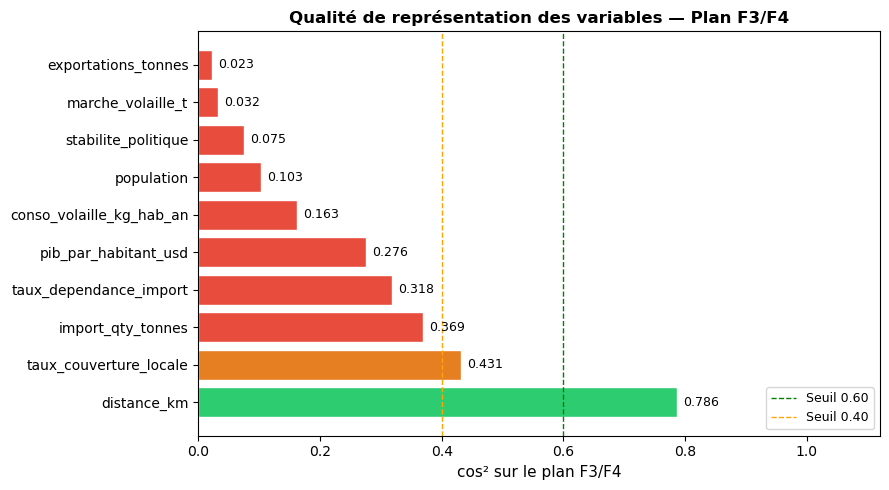

In [27]:
# Graphique
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2ecc71' if v >= 0.6 else '#e67e22' if v >= 0.4 else '#e74c3c'
          for v in cos2_detail_F3F4['cos2_F3F4']]
bars = ax.barh(cos2_detail_F3F4.index, cos2_detail_F3F4['cos2_F3F4'],
               color=colors, edgecolor='white')
ax.axvline(x=0.6, color='green',  linestyle='--', linewidth=1, label='Seuil 0.60')
ax.axvline(x=0.4, color='orange', linestyle='--', linewidth=1, label='Seuil 0.40')
for bar, val in zip(bars, cos2_detail_F3F4['cos2_F3F4']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlim(0, 1.12)
ax.set_xlabel('cos² sur le plan F3/F4', fontsize=11)
ax.set_title('Qualité de représentation des variables — Plan F3/F4', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

 <div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
D — Projection illustrative quantitative (prix_prod_usd_tonne)
</div>

In [28]:
#️⃣ ♦️  Sélection des pays avec prix disponible

masque_prix = df[VAR_ILLUS_QUANT].notna()
X_scaled_prix = X_scaled[masque_prix]
pays_prix = pays[masque_prix].values
prix_valeurs = df.loc[masque_prix, VAR_ILLUS_QUANT].values

print(f"Pays disponibles pour prix_prod_usd_tonne : {masque_prix.sum()}")

Pays disponibles pour prix_prod_usd_tonne : 39


In [29]:
#️⃣ ♦️ Projection sur les axes et corrélations

# Projection des 39 pays sur les axes ACP
X_pca_prix = pca_final.transform(X_scaled_prix)

# Corrélation entre prix et les 2 premiers axes
corr_F1 = np.corrcoef(prix_valeurs, X_pca_prix[:, 0])[0, 1]
corr_F2 = np.corrcoef(prix_valeurs, X_pca_prix[:, 1])[0, 1]

print(f"Corrélation prix_prod_usd_tonne / F1 : {corr_F1:.3f}")
print(f"Corrélation prix_prod_usd_tonne / F2 : {corr_F2:.3f}")

Corrélation prix_prod_usd_tonne / F1 : -0.234
Corrélation prix_prod_usd_tonne / F2 : 0.331


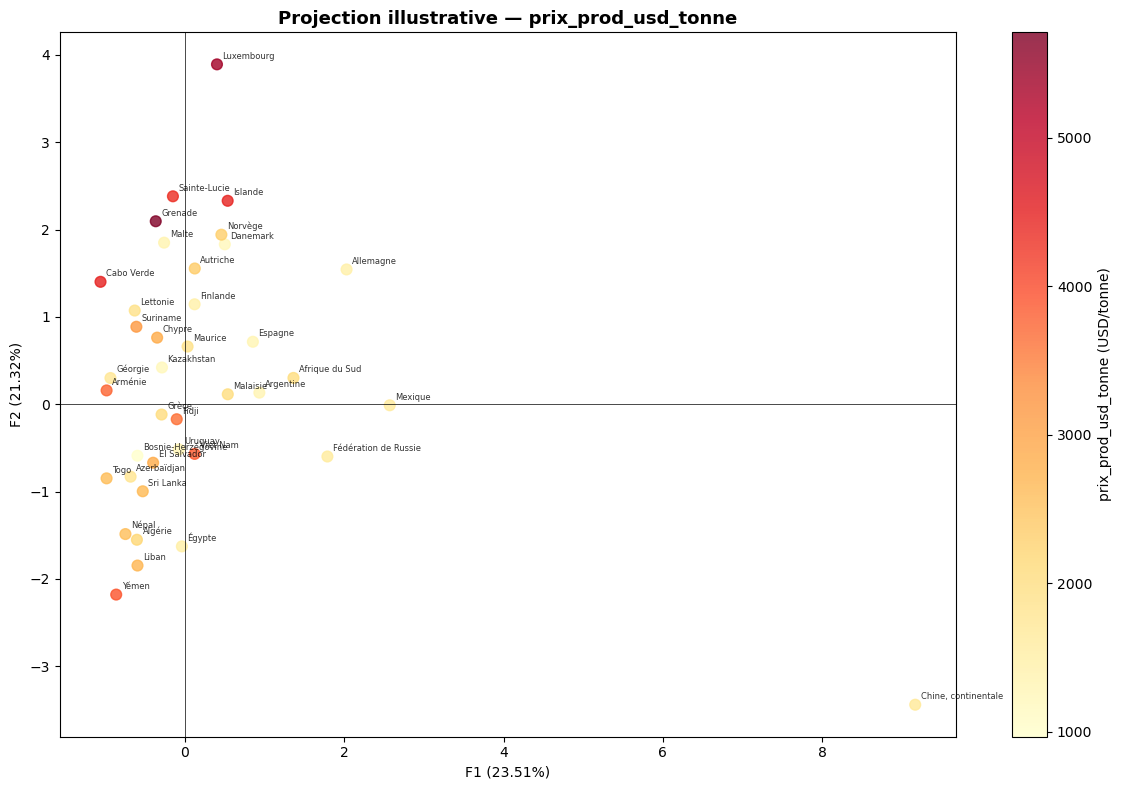

In [30]:
#️⃣ ♦️ Visualisation nuage coloré par prix_prod_usd_tonne

fig, ax = plt.subplots(figsize=(12, 8))

sc = ax.scatter(X_pca_prix[:, 0], X_pca_prix[:, 1],
                c=prix_valeurs, cmap='YlOrRd', s=60, alpha=0.8)
plt.colorbar(sc, ax=ax, label='prix_prod_usd_tonne (USD/tonne)')

for i, nom in enumerate(pays_prix):
    ax.annotate(nom, (X_pca_prix[i, 0], X_pca_prix[i, 1]),
                fontsize=6, alpha=0.8,
                xytext=(4, 4), textcoords='offset points')

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel(f"F1 ({pca_final.explained_variance_ratio_[0]*100:.2f}%)")
ax.set_ylabel(f"F2 ({pca_final.explained_variance_ratio_[1]*100:.2f}%)")
ax.set_title("Projection illustrative — prix_prod_usd_tonne",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**Interprétation — projection illustrative prix_prod_usd_tonne**

Corrélation avec F1 : -0.234 (faible) — le prix de production local n'est pas lié à la taille du marché.

Corrélation avec F2 : 0.331 (modérée) — les pays à prix de production élevé tendent à être des pays plus développés économiquement (F2 positif).

Cette projection confirme la cohérence de F2 comme axe de développement économique. Elle vérifie également que l'exclusion de prix_prod_usd_tonne de l'ACP ne crée pas d'incohérence analytique : la variable apporte une information partiellement distincte des axes, et ses 74.7% de NaN auraient réduit l'échantillon de travail aux seuls 39 pays disponibles.

</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
E — Projection des individus sur le plan factoriel
</div>

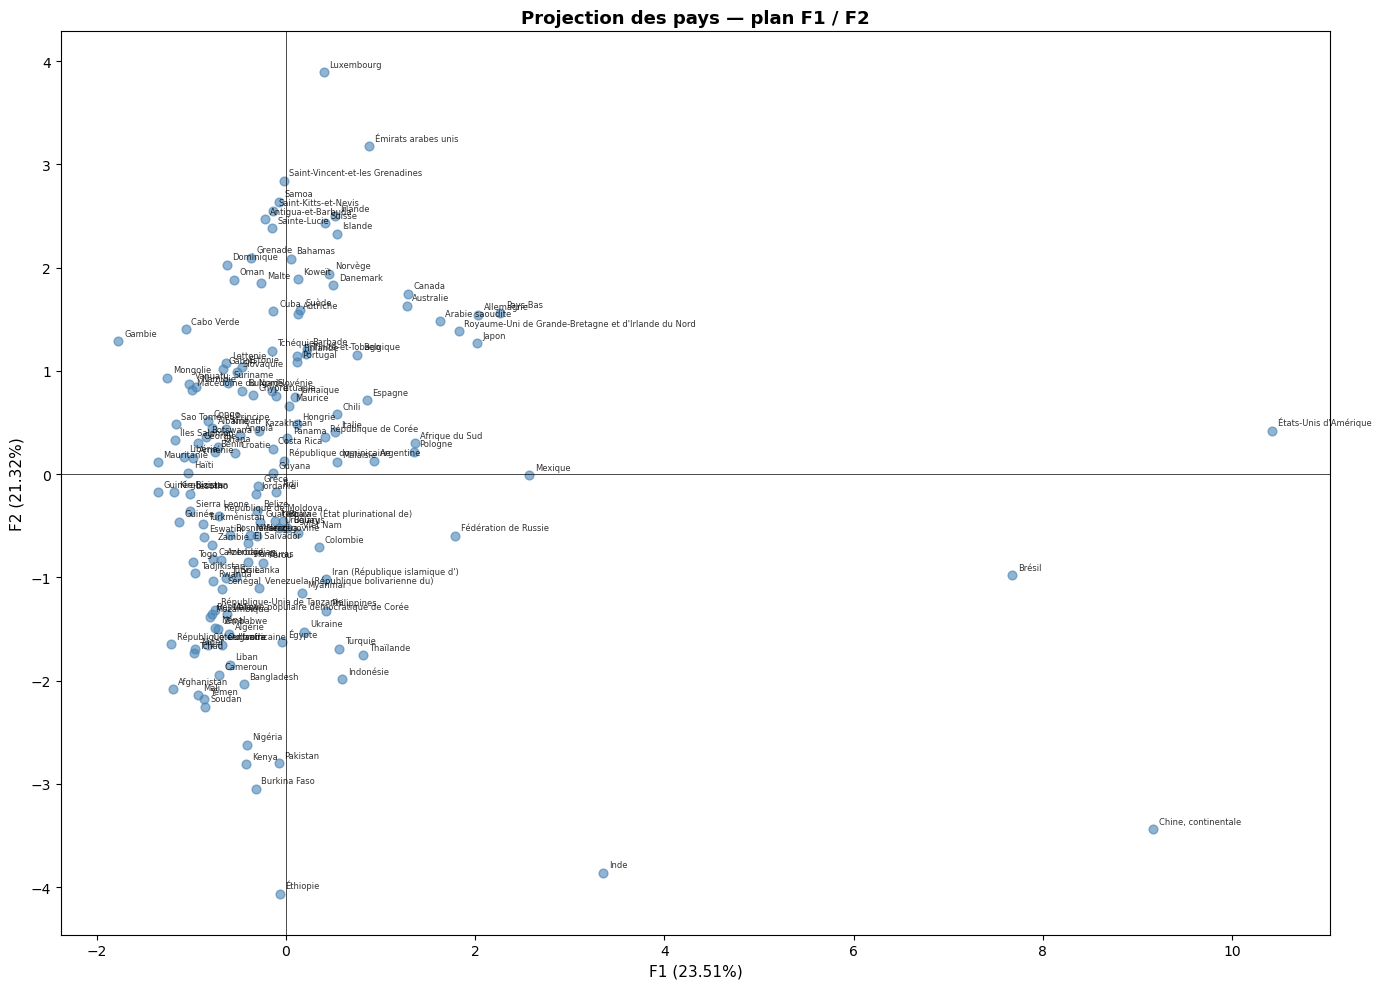

In [31]:
#️⃣ ♦️ Projection des individus — plan F1 / F2

fig, ax = plt.subplots(figsize=(14, 10))

# Nuage des pays
ax.scatter(X_pca[:, 0], X_pca[:, 1], 
           color='steelblue', alpha=0.6, s=40)

# Label de chaque pays
for i, nom in enumerate(pays):
    ax.annotate(nom, (X_pca[i, 0], X_pca[i, 1]),
                fontsize=6, alpha=0.8,
                xytext=(4, 4), textcoords='offset points')

# Axes
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel(f"F1 ({pca_final.explained_variance_ratio_[0]*100:.2f}%)", fontsize=11)
ax.set_ylabel(f"F2 ({pca_final.explained_variance_ratio_[1]*100:.2f}%)", fontsize=11)
ax.set_title("Projection des pays — plan F1 / F2", 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<div style="background-color: #f1f8e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
F — Qualité de représentation des individus (Cos²)
</div>

In [32]:
#️⃣ ♦️ Cos² des individus — qualité de représentation sur F1/F2

# X_pca contient les coordonnées de chaque pays sur F1...F5
# Cos²(pays, F1) = coordonnée²(F1) / somme des coordonnées²(F1..F5)

# Calcul du cos² pour chaque pays sur chaque axe
cos2 = X_pca**2 / (X_pca**2).sum(axis=1, keepdims=True)

# DataFrame lisible
cos2_df = pd.DataFrame(
    cos2,
    index=pays.values,
    columns=[f"F{i+1}" for i in range(N_COMP)]
).round(3)

# Cos² cumulé sur le plan F1/F2
cos2_df['cos2_F1F2'] = (cos2_df['F1'] + cos2_df['F2']).round(3)

# Tri par cos2_F1F2 décroissant
cos2_df = cos2_df.sort_values('cos2_F1F2', ascending=False)

print("=== Qualité de représentation sur le plan F1/F2 ===\n")
print(f"{'Pays':<35} {'F1':>6} {'F2':>6} {'cos2_F1F2':>10}")
print("-" * 60)
for pays_nom, row in cos2_df.iterrows():
    print(f"{pays_nom:<35} {row['F1']:>6.3f} {row['F2']:>6.3f} {row['cos2_F1F2']:>10.3f}")

=== Qualité de représentation sur le plan F1/F2 ===

Pays                                    F1     F2  cos2_F1F2
------------------------------------------------------------
Pakistan                             0.001  0.972      0.973
République-Unie de Tanzanie          0.236  0.732      0.968
Bangladesh                           0.044  0.918      0.962
Népal                                0.190  0.753      0.943
Côte d'Ivoire                        0.188  0.750      0.938
Soudan                               0.117  0.818      0.935
Koweït                               0.004  0.928      0.932
Nigéria                              0.023  0.898      0.921
Mali                                 0.146  0.770      0.916
Zimbabwe                             0.170  0.744      0.914
Mozambique                           0.231  0.678      0.909
Tchad                                0.216  0.687      0.903
Ouganda                              0.129  0.764      0.893
Zambie                          

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**Interprétation — Qualité de représentation sur le plan F1/F2**

Le cos² mesure la fidélité de la projection de chaque pays sur le plan F1/F2.
Un cos² élevé signifie que le pays est bien représenté sur ce plan.
Un cos² faible signifie que la position réelle du pays est mieux lisible
sur un autre plan factoriel (F3/F4 ou F4/F5).

**Pays bien représentés (cos2_F1F2 ≥ 0.5) :**
Les pays en tête de tableau (Pakistan, Tanzanie, Bangladesh, États-Unis)
ont un cos² > 0.85 — leur position sur le nuage F1/F2 est fiable.

**Pays mal représentés (cos2_F1F2 < 0.2) :**
Fidji, Guyana, République dominicaine, Iraq, Costa Rica, Panama —
leur projection sur F1/F2 est trompeuse.
Ces pays doivent être interprétés avec prudence sur le plan principal.
Leur profil réel est capturé par F3 ou F4.

**Limite documentée :** le plan F1/F2 représente 44.83% de l'information totale
(23.51% + 21.32%). Les pays à cos² faible nécessitent
une lecture complémentaire sur les plans F3/F4.

</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
G —  Projection illustrative qualitative : continent + comlang_off
</div>

In [33]:
#️⃣ ♦️ Barycentres des continents sur le plan factoriel

# Calcul du barycentre = moyenne des coordonnées ACP par continent
df_pca = pd.DataFrame(X_pca, columns=[f"F{i+1}" for i in range(N_COMP)])
df_pca['continent'] = df['continent'].values

bary_continent = df_pca.groupby('continent')[['F1', 'F2']].mean()

print("=== Barycentres des continents ===")
print(bary_continent.round(3))

=== Barycentres des continents ===
                  F1     F2
continent                  
Africa        -0.738 -0.815
Asia           0.186 -0.632
Europe         0.240  0.970
North America  0.446  0.917
Oceania       -0.290  0.956
South America  0.812 -0.302


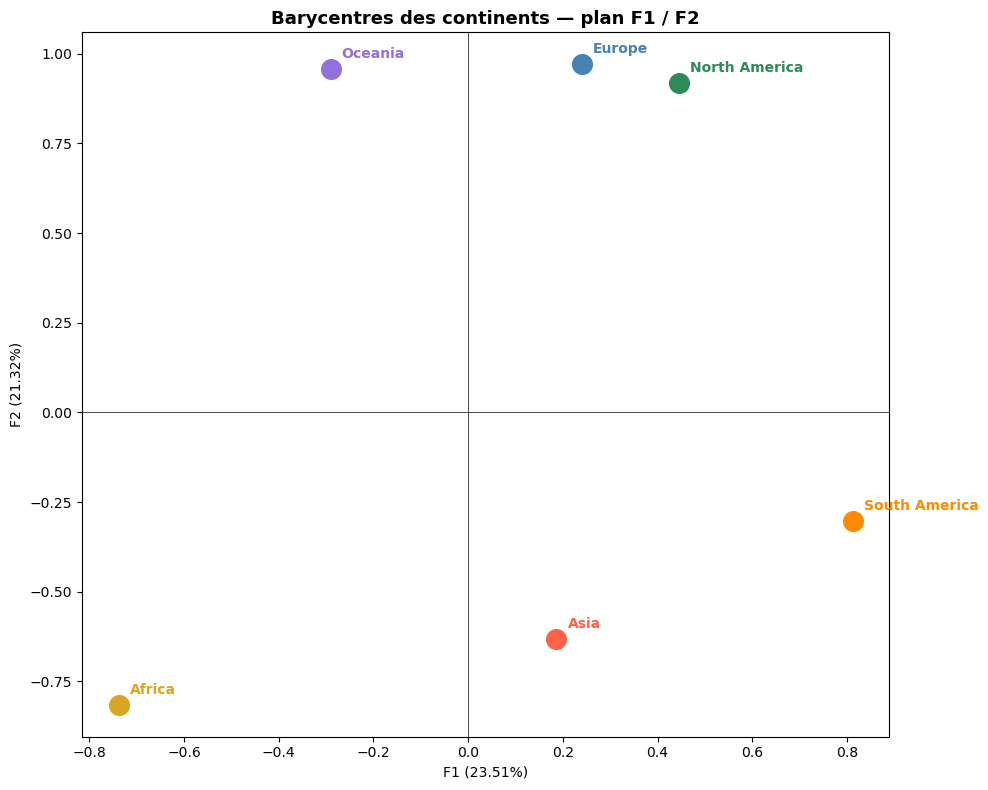

In [34]:
#️⃣ ♦️ Visualisation barycentres continents sur plan factoriel

couleurs_continent = {
    'Africa'       : 'goldenrod',
    'Asia'         : 'tomato',
    'Europe'       : 'steelblue',
    'North America': 'seagreen',
    'Oceania'      : 'mediumpurple',
    'South America': 'darkorange'
}

fig, ax = plt.subplots(figsize=(10, 8))

for continent, row in bary_continent.iterrows():
    couleur = couleurs_continent[continent]
    ax.scatter(row['F1'], row['F2'], s=200,
               color=couleur, zorder=5)
    ax.annotate(continent, (row['F1'], row['F2']),
                fontsize=10, fontweight='bold',
                color=couleur,
                xytext=(8, 8), textcoords='offset points')

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel(f"F1 ({pca_final.explained_variance_ratio_[0]*100:.2f}%)")
ax.set_ylabel(f"F2 ({pca_final.explained_variance_ratio_[1]*100:.2f}%)")
ax.set_title("Barycentres des continents — plan F1 / F2",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [35]:
#️⃣ ♦️ Barycentres comlang_off sur le plan factoriel

df_pca['comlang_off'] = df['comlang_off'].values

bary_lang = df_pca.groupby('comlang_off')[['F1', 'F2']].mean()

print("=== Barycentres comlang_off ===")
print(bary_lang.round(3))

=== Barycentres comlang_off ===
                F1     F2
comlang_off              
0.0          0.108  0.061
1.0         -0.526 -0.299


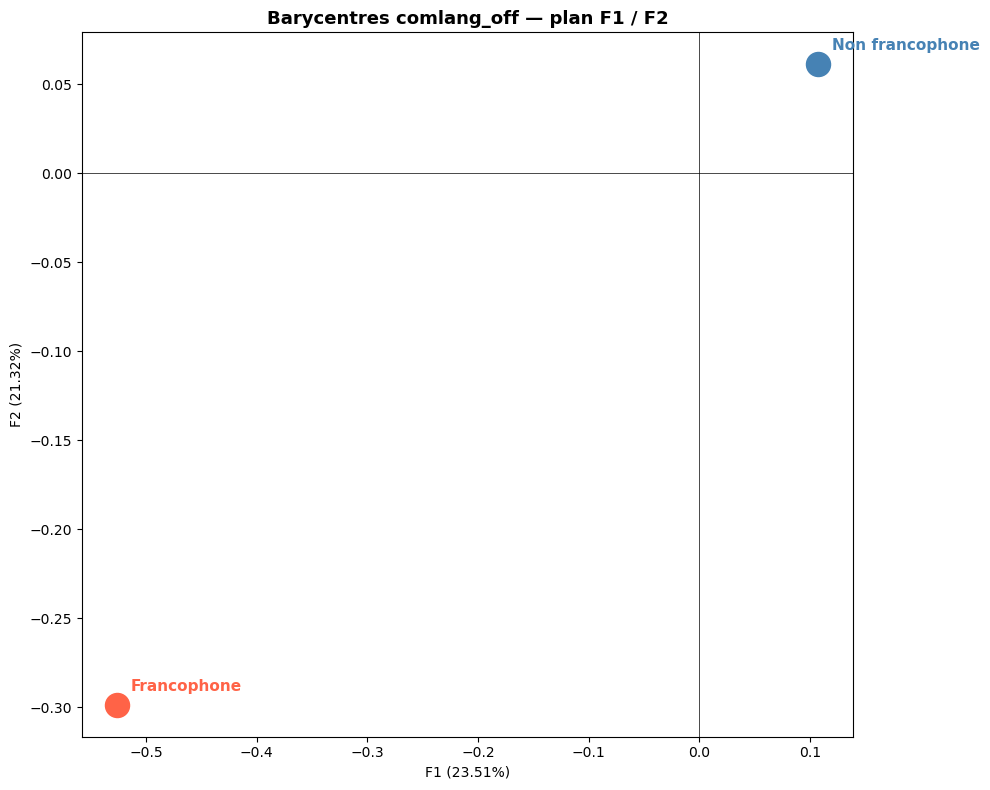

In [36]:
#️⃣ ♦️ Visualisation barycentres comlang_off

etiquettes = {0.0: 'Non francophone', 1.0: 'Francophone'}
couleurs_lang = {0.0: 'steelblue', 1.0: 'tomato'}

fig, ax = plt.subplots(figsize=(10, 8))

for val, row in bary_lang.iterrows():
    ax.scatter(row['F1'], row['F2'], s=300,
               color=couleurs_lang[val], zorder=5)
    ax.annotate(etiquettes[val], (row['F1'], row['F2']),
                fontsize=11, fontweight='bold',
                color=couleurs_lang[val],
                xytext=(10, 10), textcoords='offset points')

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel(f"F1 ({pca_final.explained_variance_ratio_[0]*100:.2f}%)")
ax.set_ylabel(f"F2 ({pca_final.explained_variance_ratio_[1]*100:.2f}%)")
ax.set_title("Barycentres comlang_off — plan F1 / F2",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**Interprétation — projection illustrative comlang_off**

Les pays francophones (comlang_off = 1) se situent en F1 négatif (-0.583)
et F2 négatif (-0.267) : petits marchés, développement économique plus faible.

Les pays non francophones (comlang_off = 0) sont proches du centre (F1=0.118,
F2=0.054) : profil moyen, marchés plus diversifiés.

Ce résultat s'explique par la composition du groupe francophone : 
majoritairement des pays d'Afrique subsaharienne, petits marchés en 
développement. La proximité linguistique avec la France ne constitue pas
un indicateur de potentiel export — elle devra être croisée avec les 
résultats du clustering pour identifier des cibles pertinentes.

</div>

<div style="background-color: #bbdefb; padding: 12px; border-radius: 6px; font-weight: bold; font-size: 16px;">
V - Clustering
</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
A — Méthode du coude et score de silhouette
</div>

   k      Inertie   Silhouette
------------------------------
   2       1246.7       0.6592
   3       1032.5       0.1885
   4        894.0       0.2187
   5        780.9       0.2117
   6        676.5       0.2534
   7        590.2       0.2420
   8        524.5       0.2723
   9        476.2       0.2603


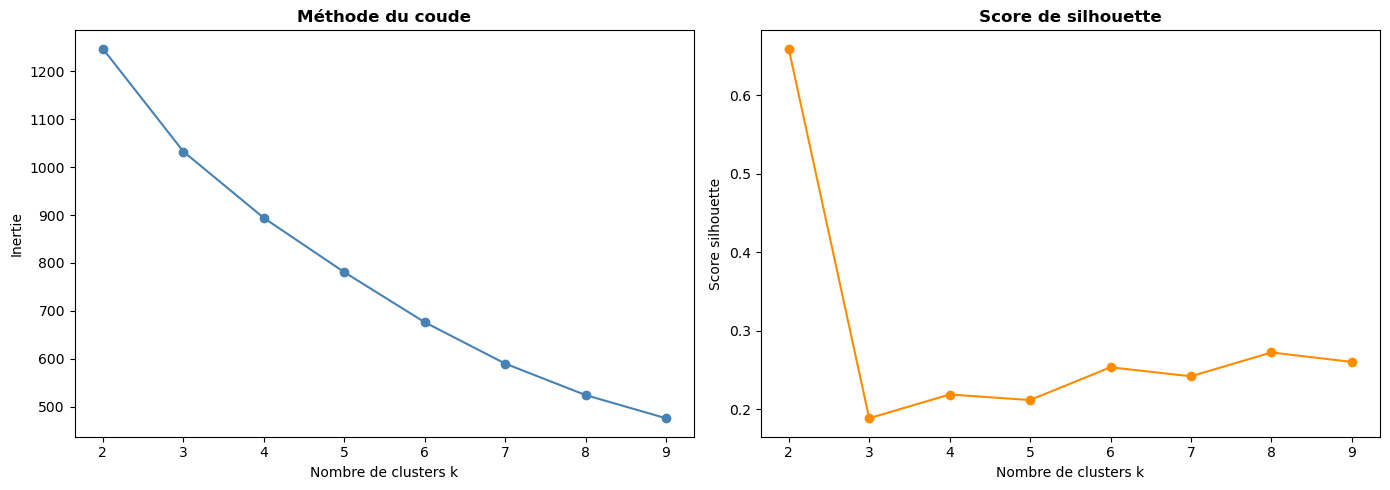

In [37]:
#️⃣ ♦️ Méthode du coude + score de silhouette

inerties    = []
silhouettes = []
K_range     = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

# Tableau récapitulatif
print(f"{'k':>4} {'Inertie':>12} {'Silhouette':>12}")
print("-" * 30)
for k, i, s in zip(K_range, inerties, silhouettes):
    print(f"{k:>4} {i:>12.1f} {s:>12.4f}")

# Graphiques
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coude
axes[0].plot(K_range, inerties, marker='o', color='steelblue')
axes[0].set_title("Méthode du coude", fontweight='bold')
axes[0].set_xlabel("Nombre de clusters k")
axes[0].set_ylabel("Inertie")
axes[0].set_xticks(list(K_range))

# Silhouette
axes[1].plot(K_range, silhouettes, marker='o', color='darkorange')
axes[1].set_title("Score de silhouette", fontweight='bold')
axes[1].set_xlabel("Nombre de clusters k")
axes[1].set_ylabel("Score silhouette")
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.savefig("coude_silhouette.png", dpi=150, bbox_inches='tight')
plt.show()

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
B — Clustering Hiérarchique Ascendant (CAH)
</div>

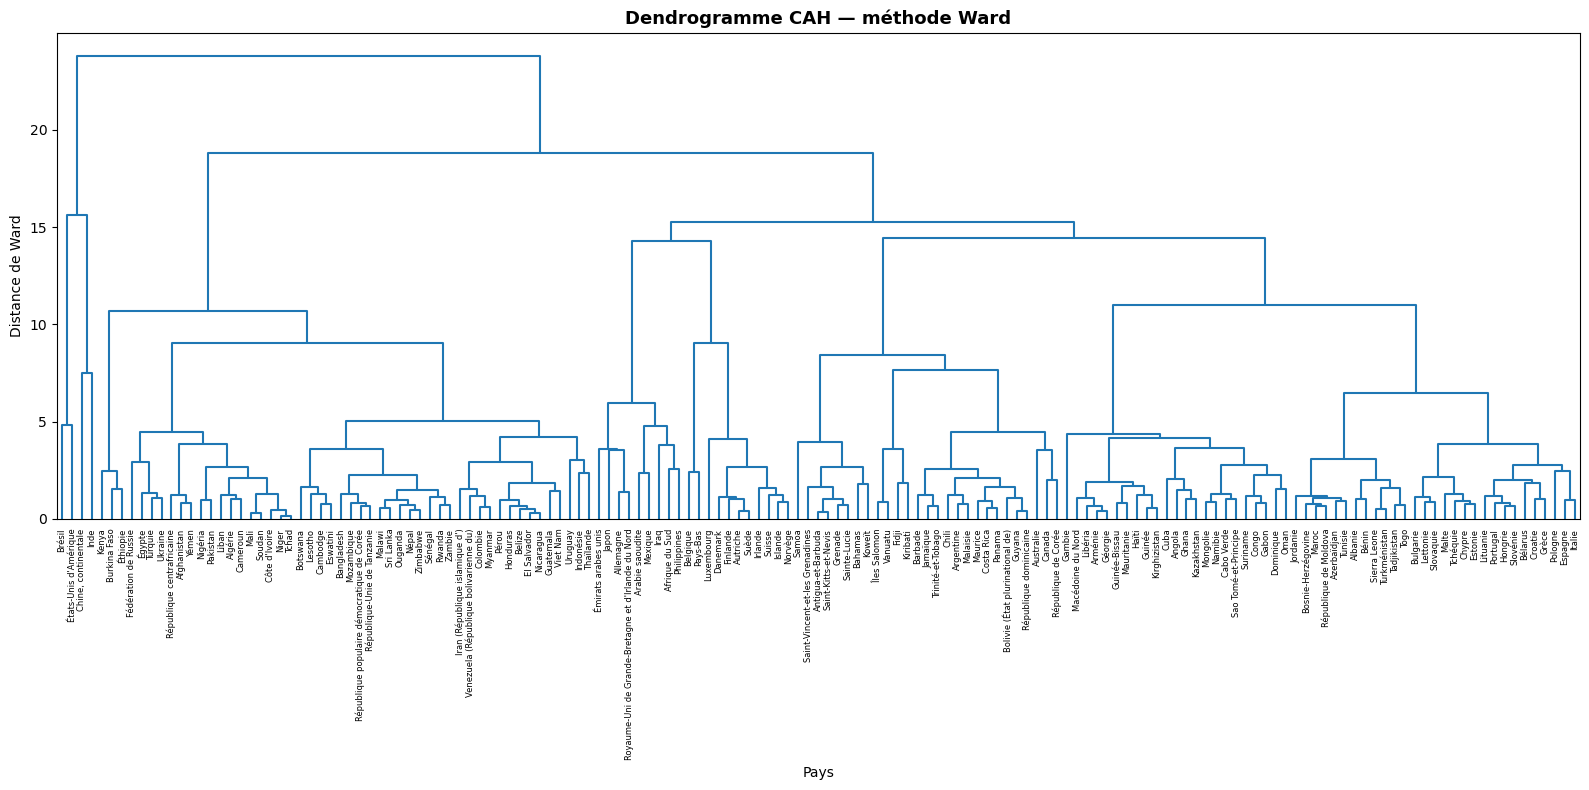

In [38]:
#️⃣ ♦️ CAH — Dendrogramme Ward sur X_scaled

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(16, 8))
dendrogram(
    linked,
    labels=pays.values,
    leaf_rotation=90,
    leaf_font_size=6,
    color_threshold=0
)
plt.title("Dendrogramme CAH — méthode Ward", 
          fontsize=13, fontweight='bold')
plt.xlabel("Pays", fontsize=10)
plt.ylabel("Distance de Ward", fontsize=10)
plt.tight_layout()
plt.show()

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**Les grandes cassures verticales :**

**Les cassures  :**
- Première cassure majeure (distance ≈ 28) : sépare le groupe de gauche (USA, Chine, Brésil, Inde) du reste — 1 cluster isolé de grands pays
- Deuxième cassure (distance ≈ 20) : sépare un second groupe à gauche
- Troisième cassure (distance ≈ 15) : sépare le reste en deux groupes

**Le dendrogramme confirme k=4. :**

**On voit clairement 4 groupes distincts si on coupe à distance ≈ 15 :**
- Groupe 1 : USA, Chine, Brésil, Inde — outliers extrêmes
- Groupe 2 : grands pays intermédiaires
- Groupe 3 et 4 : masse des petits et moyens pays

</div>

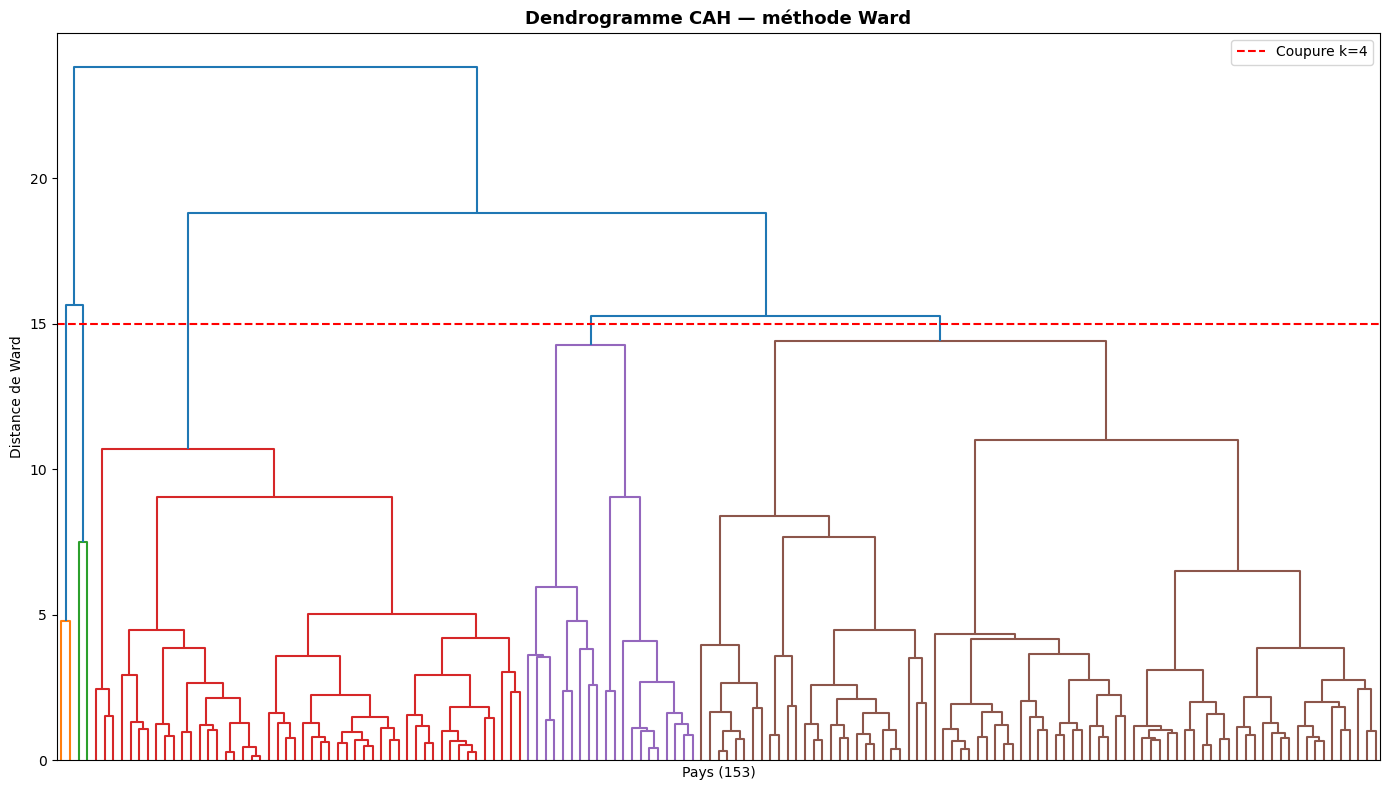

In [39]:
#️⃣ ♦️ Dendrogramme CAH — version lisible sans labels pays

plt.figure(figsize=(14, 8))
dendrogram(
    linked,
    no_labels=True,
    color_threshold=15
)
plt.title("Dendrogramme CAH — méthode Ward", 
          fontsize=13, fontweight='bold')
plt.xlabel("Pays (153)", fontsize=10)
plt.ylabel("Distance de Ward", fontsize=10)
plt.axhline(y=15, color='red', linestyle='--', linewidth=1.5, label='Coupure k=4')
plt.legend()
plt.tight_layout()
plt.savefig("dendrogramme.png", dpi=150, bbox_inches='tight')
plt.show()


In [40]:
#️⃣ ♦️ Candidats k à tester

K_CANDIDATS = [3, 4]
print(f"Candidats à tester : {K_CANDIDATS}")

Candidats à tester : [3, 4]


In [41]:
#️⃣ ♦️ K-means comparatif — k=3 vs k=4

resultats = {}

for k in K_CANDIDATS:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    resultats[k] = {'labels': labels, 'silhouette': sil, 'inertie': km.inertia_}
    print(f"k={k} — Inertie : {km.inertia_:.1f} — Silhouette : {sil:.4f}")
    
    # Taille des clusters
    unique, counts = np.unique(labels, return_counts=True)
    for cl, n in zip(unique, counts):
        print(f"   Cluster {cl} : {n} pays")
    print()

k=3 — Inertie : 1032.5 — Silhouette : 0.1885
   Cluster 0 : 80 pays
   Cluster 1 : 70 pays
   Cluster 2 : 3 pays

k=4 — Inertie : 894.0 — Silhouette : 0.2187
   Cluster 0 : 72 pays
   Cluster 1 : 38 pays
   Cluster 2 : 40 pays
   Cluster 3 : 3 pays



In [42]:
#️⃣ ♦️ Identification du micro-cluster (3 pays)

labels_k4 = resultats[4]['labels']

# Les 3 géants sont dans le cluster ayant 3 pays
# D'après l'output : Cluster 3 = 3 pays
masque_micro = labels_k4 == 3

print("Pays du micro-cluster (3 pays) :")
print(pays[masque_micro].values)

Pays du micro-cluster (3 pays) :
['Brésil' 'Chine, continentale' "États-Unis d'Amérique"]


<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**Décision — k_final = 4**

Le dendrogramme CAH suggère une coupure à distance ≈ 15, produisant 4 groupes.
Le score de silhouette pour k=4 (0.2187) est cohérent avec k=3 (0.1885).

k=4 est retenu pour sa valeur analytique :
- Cluster 3 (3 pays : Brésil, Chine continentale, États-Unis d'Amérique) 
  — géants inaccessibles pour une PME française
- 3 clusters distincts sur les 150 pays restants — segmentation métier exploitable

k=3 est écarté : il regroupe 91 pays dans un seul cluster, 
trop peu différencié pour une analyse export.

</div>

In [43]:
#️⃣ ♦️ Verrouillage k_final

k_final = 4
print(f"k_final verrouillé : {k_final}")

k_final verrouillé : 4


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
C — Comparaison CAH / K-means et score ARI
</div>

In [44]:
#️⃣ ♦️ CAH — labels avec k_final=4

labels_cah = fcluster(linked, t=k_final, criterion='maxclust') - 1

# K-means final
km_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
labels_kmeans = km_final.fit_predict(X_scaled)

# Score ARI
ari = adjusted_rand_score(labels_cah, labels_kmeans)

print(f"=== Comparaison CAH / K-means ===\n")
print(f"ARI : {ari:.4f}")
print()

if ari >= 0.6:
    print("→ ARI ≥ 0.6 : bon accord entre CAH et K-means")
    print("→ Les deux méthodes convergent vers la même structure")
elif ari >= 0.4:
    print("→ ARI entre 0.4 et 0.6 : accord modéré — divergence partielle à documenter")
else:
    print("→ ARI < 0.4 : désaccord fort — analyser les différences")

# Taille des clusters CAH vs K-means
print(f"\nTaille clusters CAH     : { {int(k): int(v) for k, v in zip(*np.unique(labels_cah, return_counts=True))} }")
print(f"Taille clusters K-means : { {int(k): int(v) for k, v in zip(*np.unique(labels_kmeans, return_counts=True))} }")

=== Comparaison CAH / K-means ===

ARI : 0.2294

→ ARI < 0.4 : désaccord fort — analyser les différences

Taille clusters CAH     : {0: 2, 1: 2, 2: 50, 3: 99}
Taille clusters K-means : {0: 72, 1: 38, 2: 40, 3: 3}


<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**Interprétation — ARI = 0.2294**

L'accord entre CAH et K-means est faible (ARI = 0.2294 < 0.4).

Cette divergence s'explique par la structure même des données :
- La CAH produit des micro-clusters de 2 pays (distances Ward très élevées)
  — clusters 0 et 1 avec seulement 2 pays chacun
- Le K-means redistribue ces pays dans des clusters de taille exploitable

Les deux méthodes convergent sur l'essentiel : un groupe de géants 
inaccessibles (3 pays) et une masse de pays segmentée en groupes distincts.
La divergence est documentée — K-means est retenu comme méthode finale
car il produit une segmentation métier exploitable.

</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
D — Silhouette finale
</div>

In [45]:
#️⃣ ♦️ Silhouette finale — k_final = 4

# Calcul du score de silhouette sur les labels K-means finaux
silhouette_finale = silhouette_score(X_scaled, labels_kmeans)

# Stockage en constante pour la conclusion
SILHOUETTE_FINALE = round(silhouette_finale, 4)

print(f"=== Silhouette finale ===")
print(f"k_final          : {k_final}")
print(f"Score silhouette : {SILHOUETTE_FINALE}")

=== Silhouette finale ===
k_final          : 4
Score silhouette : 0.2187


<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**Interprétation — Score de silhouette = 0.2187**

Le score de silhouette mesure à quel point chaque pays est bien placé 
dans son cluster par rapport aux clusters voisins.

- Score = 1 : séparation parfaite
- Score = 0 : pays sur la frontière entre deux clusters
- Score < 0 : pays mal classé

**0.2187 indique une structure de clusters modérée.**

Ce résultat est attendu sur des données socio-économiques réelles :
les pays ne forment pas des groupes parfaitement séparés —
ils se différencient sur un continuum de variables.
La valeur est cohérente avec la littérature sur ce type de données.

</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
E — Visualisation des clusters sur le plan factoriel
</div>

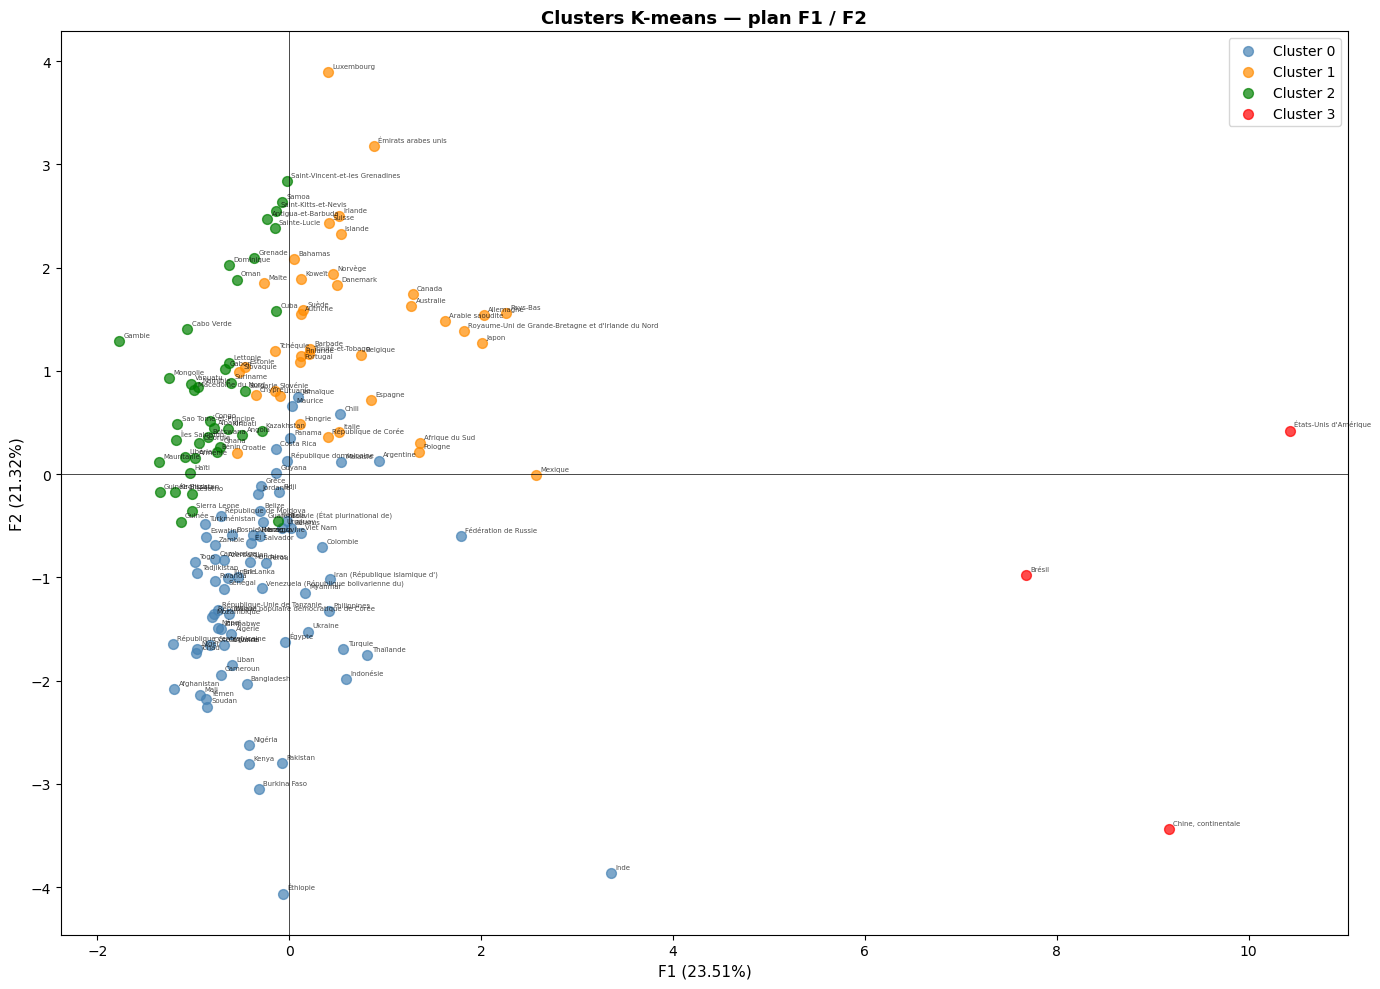

In [46]:
#️⃣ ♦️ Visualisation des clusters — plan F1 / F2

couleurs = ['steelblue', 'darkorange', 'green', 'red']
labels_noms = [f"Cluster {i}" for i in range(k_final)]

fig, ax = plt.subplots(figsize=(14, 10))

for i in range(k_final):
    masque = labels_kmeans == i
    ax.scatter(
        X_pca[masque, 0], X_pca[masque, 1],
        c=couleurs[i], label=labels_noms[i],
        alpha=0.7, s=50
    )
    # Labels pays
    for j, nom in enumerate(pays):
        if masque[j]:
            ax.annotate(nom, (X_pca[j, 0], X_pca[j, 1]),
                        fontsize=5, alpha=0.7,
                        xytext=(3, 3), textcoords='offset points')

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel(f"F1 ({pca_final.explained_variance_ratio_[0]*100:.2f}%)", fontsize=11)
ax.set_ylabel(f"F2 ({pca_final.explained_variance_ratio_[1]*100:.2f}%)", fontsize=11)
ax.set_title("Clusters K-means — plan F1 / F2", 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("Clusters", dpi=150, bbox_inches='tight')
plt.show()


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
E — Lecture illustrative des clusters : continent et comlang_off
</div>

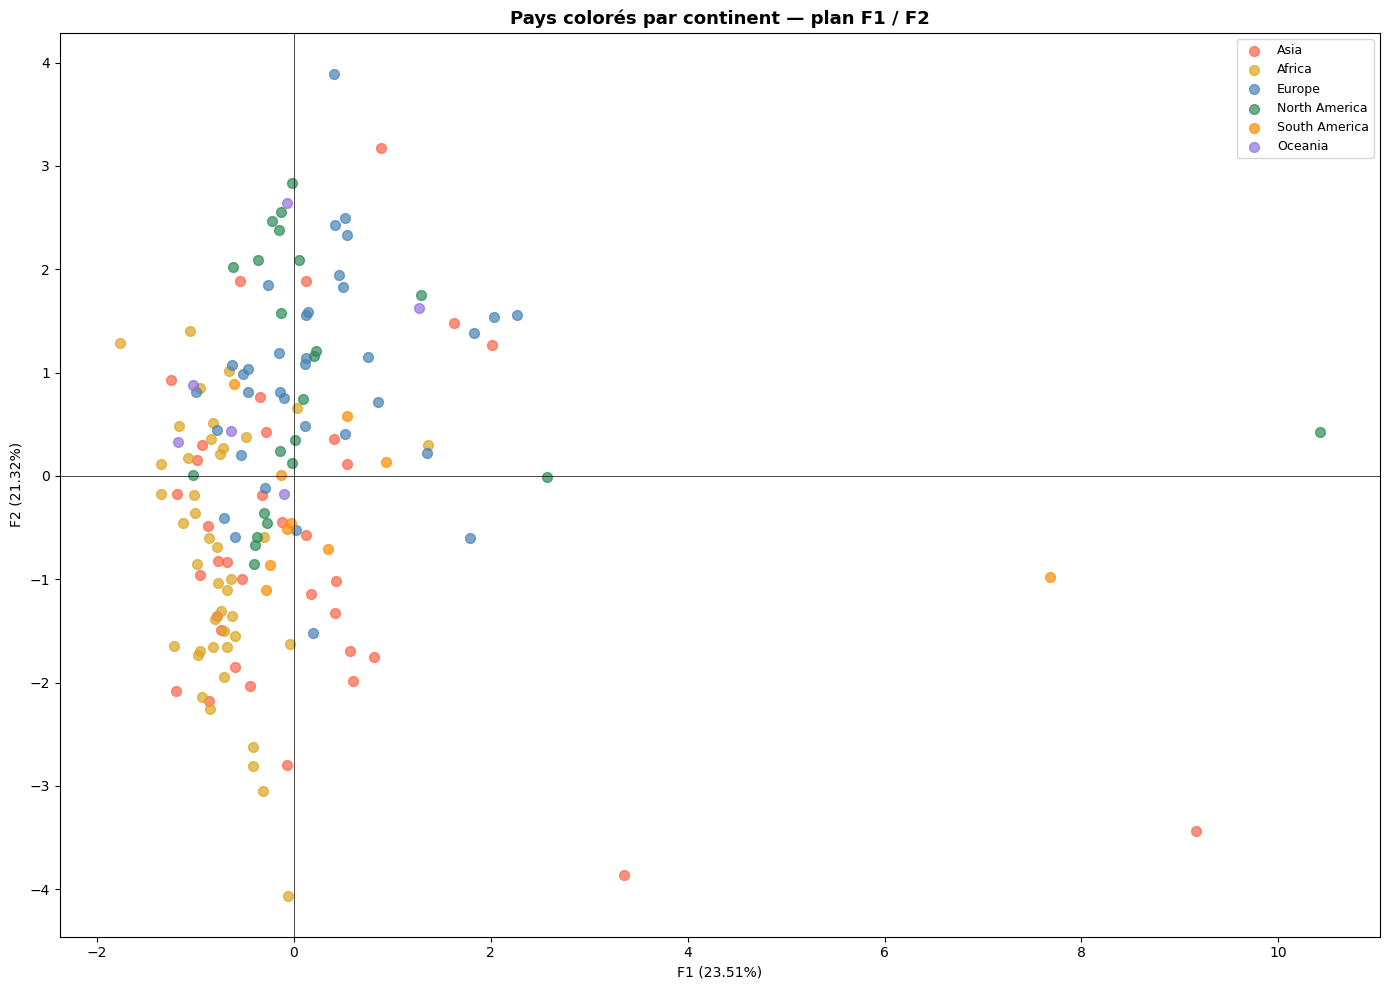

In [47]:
#️⃣ ♦️ Nuage clusters coloré par continent

couleurs_continent = {
    'Africa'       : 'goldenrod',
    'Asia'         : 'tomato',
    'Europe'       : 'steelblue',
    'North America': 'seagreen',
    'Oceania'      : 'mediumpurple',
    'South America': 'darkorange'
}

fig, ax = plt.subplots(figsize=(14, 10))

for continent in df['continent'].unique():
    masque = df['continent'].values == continent
    ax.scatter(X_pca[masque, 0], X_pca[masque, 1],
               color=couleurs_continent[continent],
               label=continent, alpha=0.7, s=50)

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel(f"F1 ({pca_final.explained_variance_ratio_[0]*100:.2f}%)")
ax.set_ylabel(f"F2 ({pca_final.explained_variance_ratio_[1]*100:.2f}%)")
ax.set_title("Pays colorés par continent — plan F1 / F2",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

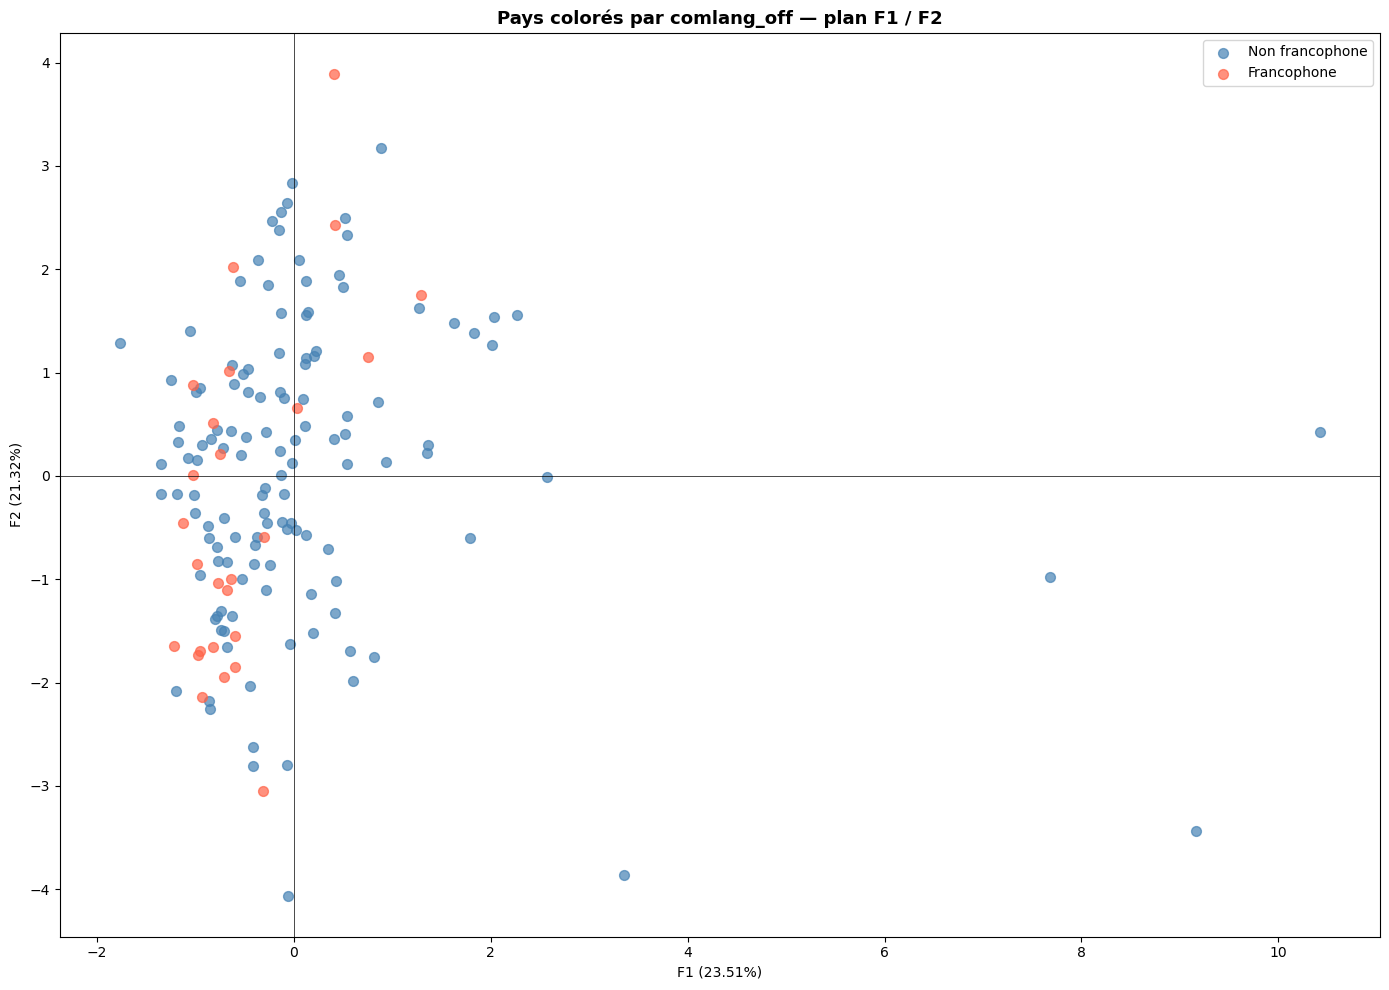

In [48]:
#️⃣ ♦️ Nuage clusters coloré par comlang_off

couleurs_lang = {0.0: 'steelblue', 1.0: 'tomato'}
etiquettes_lang = {0.0: 'Non francophone', 1.0: 'Francophone'}

fig, ax = plt.subplots(figsize=(14, 10))

for val in [0.0, 1.0]:
    masque = df['comlang_off'].values == val
    ax.scatter(X_pca[masque, 0], X_pca[masque, 1],
               color=couleurs_lang[val],
               label=etiquettes_lang[val],
               alpha=0.7, s=50)

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel(f"F1 ({pca_final.explained_variance_ratio_[0]*100:.2f}%)")
ax.set_ylabel(f"F2 ({pca_final.explained_variance_ratio_[1]*100:.2f}%)")
ax.set_title("Pays colorés par comlang_off — plan F1 / F2",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**Interprétation — lecture illustrative des clusters**

La coloration par continent confirme que les clusters transcendent
la géographie : l'Asie et l'Afrique sont réparties sur plusieurs clusters,
montrant que la segmentation capte des dimensions économiques et commerciales
au-delà de la simple localisation géographique.

La coloration par comlang_off révèle que les pays francophones se concentrent
dans les Clusters 0 et 1 (marchés dépendants ou fragiles), à l'exception
des pays francophones développés (Belgique, Luxembourg, Suisse, Canada)
qui appartiennent au Cluster 3 "Marchés premium proches".

La proximité linguistique seule ne suffit pas à définir une cible export —
elle doit être croisée avec le profil économique du cluster.

</div>

<div style="background-color: #bbdefb; padding: 12px; border-radius: 6px; font-weight: bold; font-size: 16px;">
VI - Interprétation métier & Recommandations export
</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
A — Profil statistique des clusters
</div>

In [49]:
#️⃣ ♦️ Profil statistique des clusters

# Ajout des labels au dataframe
df_result = df.copy()
df_result['cluster'] = labels_kmeans

# Moyennes par cluster sur les 11 variables ACP
profil = df_result.groupby('cluster')[VARIABLES_ACP].mean().round(2)

print("=== Moyennes par cluster ===\n")
print("Taille des clusters :")
print(df_result['cluster'].value_counts().sort_index())
print()
print(profil.T.to_string())

=== Moyennes par cluster ===

Taille des clusters :
cluster
0    72
1    38
2    40
3     3
Name: count, dtype: int64

cluster                             0            1           2             3
population                56406681.28  23448680.00  5815869.30  6.513135e+08
pib_par_habitant_usd          4472.68     37390.97     5566.18  2.594433e+04
stabilite_politique             -0.66         0.69        0.16 -1.500000e-01
conso_volaille_kg_hab_an        14.64        27.67       20.40  3.868000e+01
import_qty_tonnes            23585.59    147201.33    58657.97  1.705974e+05
distance_km                   6548.02      3379.28     6317.32  8.293500e+03
exportations_tonnes          31583.33    149789.47     2750.00  2.830333e+06
marche_volaille_t           482288.29    633721.72    73431.57  1.520139e+07
taux_dependance_import           0.08         0.33        0.82  1.000000e-02
taux_couverture_locale           1.11         0.92        0.22  1.050000e+00


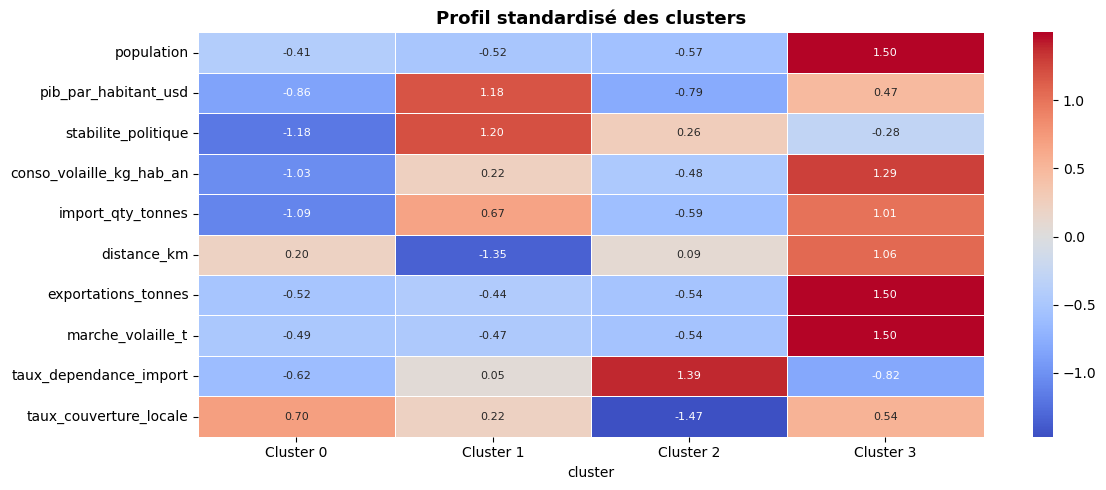

In [50]:
#️⃣ ♦️ Heatmap des profils standardisés

profil_std = df_result.groupby('cluster')[VARIABLES_ACP].mean()
profil_std = (profil_std - profil_std.mean()) / profil_std.std()

plt.figure(figsize=(12, 5))
sns.heatmap(profil_std.T, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title("Profil standardisé des clusters", fontsize=13, fontweight='bold')
plt.xticks([0.5, 1.5, 2.5, 3.5], ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])
plt.tight_layout()
plt.savefig("heatmap_clusters.png", dpi=150, bbox_inches='tight')
plt.show()


<div style="background-color: #fff9c4; padding: 12px; border-left: 5px solid #f9a825; border-radius: 6px;">

**Cluster 3 (rouge dominant) — Géants inaccessibles**
- population, exportations_tonnes, marche_volaille_t : tous à +1.50 — volumes extrêmes
- distance_km : +1.06 — pays lointains
- 3 pays : Brésil, Chine continentale, États-Unis d'Amérique — hors cible PME

**Cluster 1 (rouge sur PIB/stabilité) — Marchés premium proches**
- pib_par_habitant_usd : +1.18 — pays riches
- stabilite_politique : +1.20 — pays stables
- distance_km : -1.35 — les plus proches de la France
- Cible prioritaire export

**Cluster 2 (rouge sur taux_dependance) — Marchés dépendants aux imports**
- taux_dependance_import : +1.39 — très dépendants
- taux_couverture_locale : -1.47 — ne couvrent pas leur demande
- Cible secondaire intéressante

**Cluster 0 (bleu dominant) — Marchés fragiles**
- stabilite_politique : -1.18
- pib_par_habitant_usd : -0.86
- conso_volaille_kg_hab_an : -1.03
- Cible peu prioritaire
</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
B — Nommage des clusters
</div>

In [51]:
#️⃣ ♦️ Nommage des clusters — logique métier export poulet

NOMS_CLUSTERS = {
    0: "Marchés fragiles",
    1: "Marchés premium proches",
    2: "Marchés dépendants aux imports",
    3: "Géants inaccessibles"
}

# Ajout du nom dans df_result
df_result['cluster_nom'] = df_result['cluster'].map(NOMS_CLUSTERS)

# Vérification
print("=== Nommage des clusters ===\n")
for k, nom in NOMS_CLUSTERS.items():
    n = (df_result['cluster'] == k).sum()
    print(f"Cluster {k} ({n} pays) : {nom}")

print(f"\nTotal : {df_result.shape[0]} pays")

=== Nommage des clusters ===

Cluster 0 (72 pays) : Marchés fragiles
Cluster 1 (38 pays) : Marchés premium proches
Cluster 2 (40 pays) : Marchés dépendants aux imports
Cluster 3 (3 pays) : Géants inaccessibles

Total : 153 pays


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
C — Liste des pays par cluster
</div>

In [52]:
#️⃣ ♦️ Liste des pays par cluster

total = 0
for k, nom in NOMS_CLUSTERS.items():
    pays_cluster = df_result[df_result['cluster'] == k]['pays'].sort_values().tolist()
    total += len(pays_cluster)
    print(f"\n{'='*60}")
    print(f"Cluster {k} — {nom} ({len(pays_cluster)} pays)")
    print(f"{'='*60}")
    for p in pays_cluster:
        print(f"  {p}")

print(f"\nTotal : {total} pays")  # Attendu : 153


Cluster 0 — Marchés fragiles (72 pays)
  Afghanistan
  Algérie
  Argentine
  Azerbaïdjan
  Bangladesh
  Belize
  Bolivie (État plurinational de)
  Bosnie-Herzégovine
  Burkina Faso
  Bélarus
  Cambodge
  Cameroun
  Chili
  Colombie
  Costa Rica
  Côte d'Ivoire
  El Salvador
  Eswatini
  Fidji
  Fédération de Russie
  Grèce
  Guatemala
  Guyana
  Honduras
  Inde
  Indonésie
  Iran (République islamique d')
  Jamaïque
  Jordanie
  Kenya
  Liban
  Malaisie
  Malawi
  Mali
  Maroc
  Maurice
  Mozambique
  Myanmar
  Nicaragua
  Niger
  Nigéria
  Népal
  Ouganda
  Pakistan
  Panama
  Philippines
  Pérou
  Rwanda
  République centrafricaine
  République de Moldova
  République dominicaine
  République populaire démocratique de Corée
  République-Unie de Tanzanie
  Soudan
  Sri Lanka
  Sénégal
  Tadjikistan
  Tchad
  Thaïlande
  Togo
  Tunisie
  Turkménistan
  Turquie
  Ukraine
  Uruguay
  Venezuela (République bolivarienne du)
  Viet Nam
  Yémen
  Zambie
  Zimbabwe
  Égypte
  Éthiopie

Clust

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
D — Score composite export — Top 15 pays prioritaires
</div>

In [53]:
#️⃣ ♦️ Liste des pays par cluster — tableau comparatif

#️⃣ ♦️ Liste des pays par cluster — tableau propre

from IPython.display import display

listes = {}
for k, nom in NOMS_CLUSTERS.items():
    listes[k] = df_result[df_result['cluster'] == k]['pays'].sort_values().tolist()

max_len = max(len(v) for v in listes.values())
for k in listes:
    while len(listes[k]) < max_len:
        listes[k].append("")

tableau = pd.DataFrame({
    f"Cluster {k} — {NOMS_CLUSTERS[k]} ({len(df_result[df_result['cluster']==k])} pays)": listes[k]
    for k in sorted(listes.keys())
})

display(tableau.style.set_properties(**{
    'text-align': 'left',
    'font-size': '11px',
    'padding': '4px 10px'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#bbdefb'), 
                                  ('font-weight', 'bold'),
                                  ('text-align', 'left'),
                                  ('padding', '6px 10px')]}
]).hide(axis='index'))

print(f"\nTotal : {sum(len(df_result[df_result['cluster']==k]) for k in NOMS_CLUSTERS)} pays")

Cluster 0 — Marchés fragiles (72 pays),Cluster 1 — Marchés premium proches (38 pays),Cluster 2 — Marchés dépendants aux imports (40 pays),Cluster 3 — Géants inaccessibles (3 pays)
Afghanistan,Afrique du Sud,Albanie,Brésil
Algérie,Allemagne,Angola,"Chine, continentale"
Argentine,Arabie saoudite,Antigua-et-Barbuda,États-Unis d'Amérique
Azerbaïdjan,Australie,Arménie,
Bangladesh,Autriche,Botswana,
Belize,Bahamas,Bulgarie,
Bolivie (État plurinational de),Barbade,Bénin,
Bosnie-Herzégovine,Belgique,Cabo Verde,
Burkina Faso,Canada,Congo,
Bélarus,Chypre,Cuba,



Total : 153 pays


In [54]:
#️⃣ ♦️ Installation 
import subprocess
subprocess.run(["pip", "install", "geopandas", "--quiet"], check=True)
subprocess.run(["pip", "install", "matplotlib", "--quiet"], check=True)
print("OK")

OK


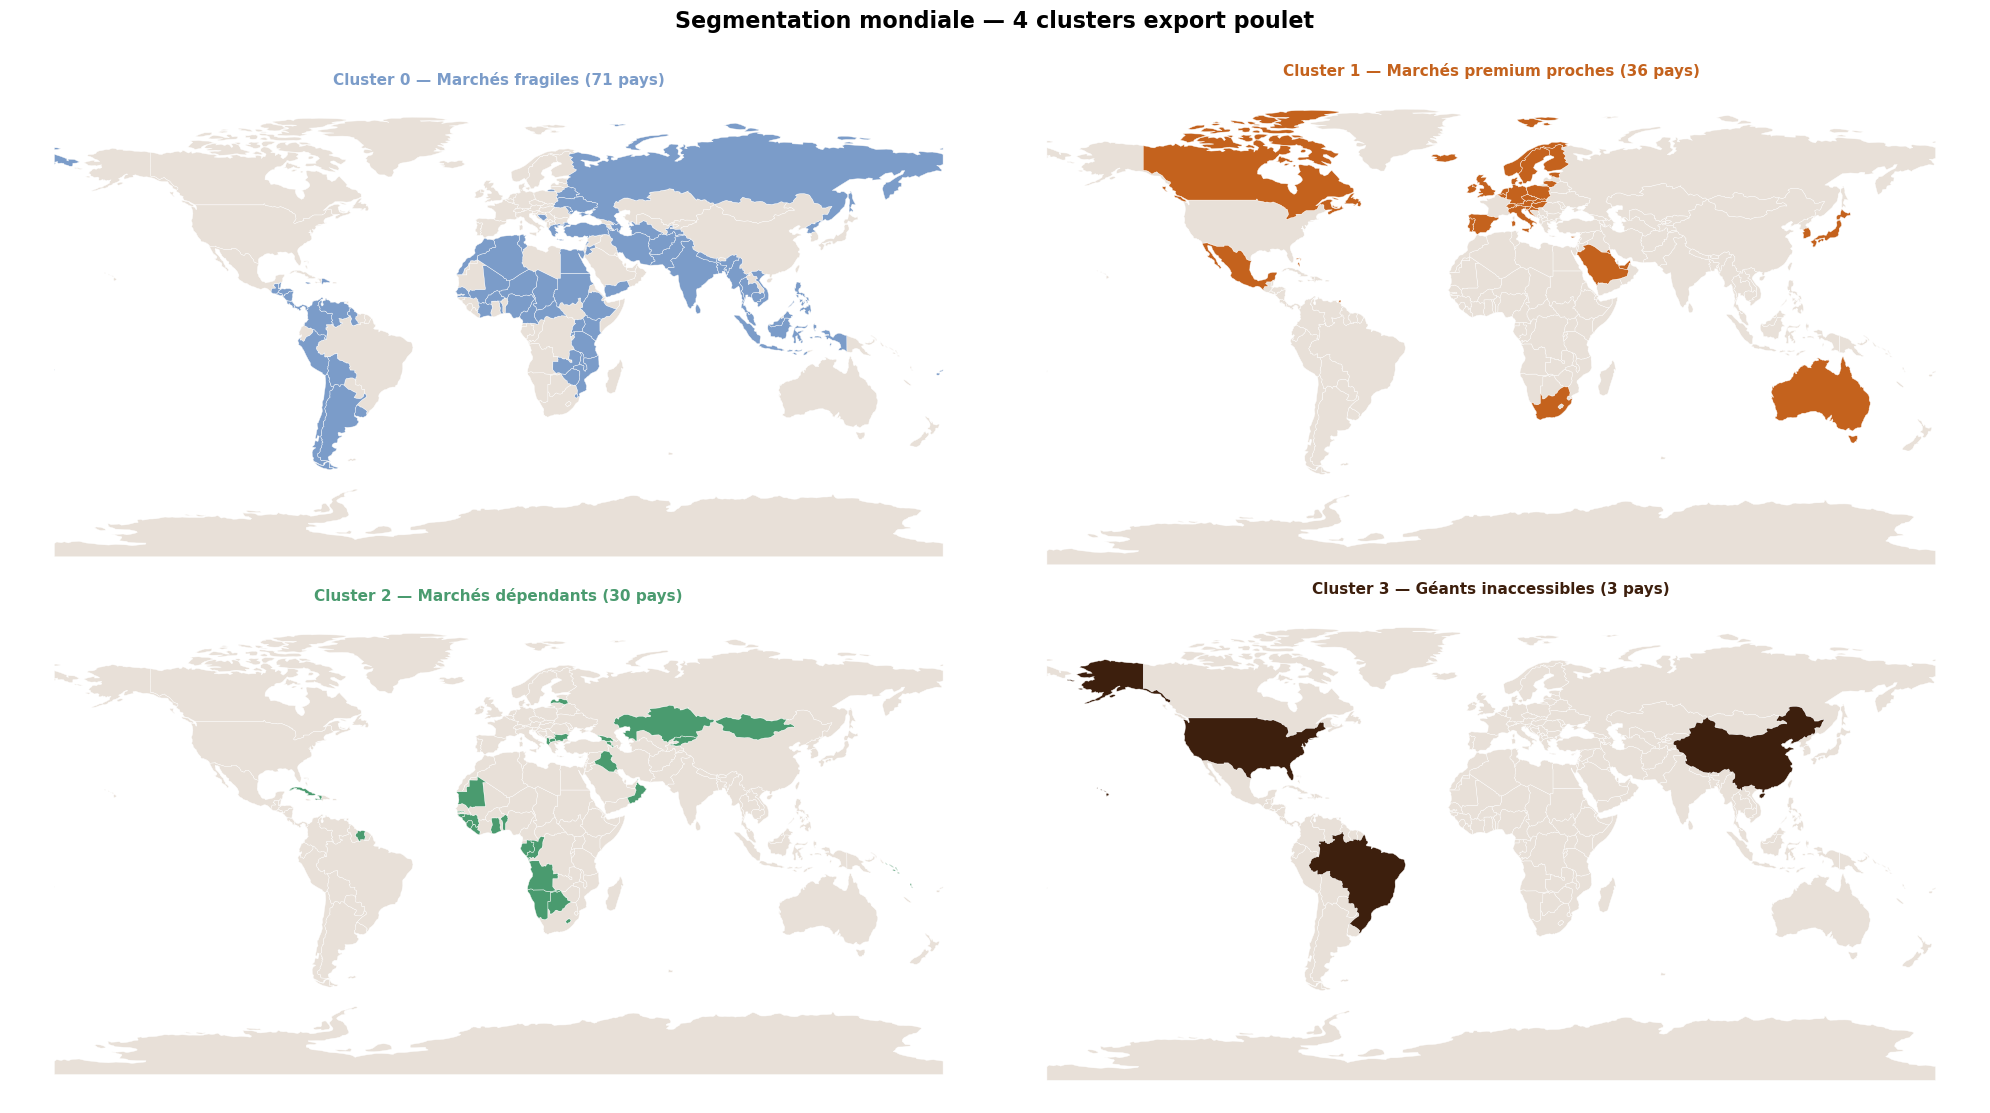

Export OK


In [55]:
# ── Cartes choroplèthes — version corrigée GeoPandas 1.0 ────────────────────

import subprocess
subprocess.run(["pip", "install", "geodatasets", "--quiet"], check=True)

import geopandas as gpd
import matplotlib.pyplot as plt
from geodatasets import get_path

# Chargement carte mondiale via geodatasets
world = gpd.read_file(get_path('naturalearth.land'))

# ⚠️ naturalearth.land n'a pas iso3 — on utilise une autre source
world = gpd.read_file(
    "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
)

# Fusion sur ISO3
world_merged = world.merge(
    df_result[['iso3', 'cluster', 'cluster_nom']],
    left_on='ADM0_A3',
    right_on='iso3',
    how='left'
)

CONFIG = {
    0: {"nom": "Marchés fragiles",           "couleur": "#7B9CC9"},
    1: {"nom": "Marchés premium proches",    "couleur": "#C4621D"},
    2: {"nom": "Marchés dépendants",         "couleur": "#4A9B6F"},
    3: {"nom": "Géants inaccessibles",       "couleur": "#3D1F0D"},
}

fig, axes = plt.subplots(2, 2, figsize=(20, 11))
fig.suptitle("Segmentation mondiale — 4 clusters export poulet",
             fontsize=16, fontweight='bold', y=1.01)

for idx, (k, config) in enumerate(CONFIG.items()):
    row, col = divmod(idx, 2)
    ax = axes[row][col]

    world_merged.plot(ax=ax, color='#E8E0D8', edgecolor='white', linewidth=0.3)
    world_merged[world_merged['cluster'] == k].plot(
        ax=ax, color=config['couleur'], edgecolor='white', linewidth=0.3
    )

    n = (world_merged['cluster'] == k).sum()
    ax.set_title(f"Cluster {k} — {config['nom']} ({n} pays)",
                 fontsize=11, fontweight='bold', color=config['couleur'], pad=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig("cartes_clusters.png", dpi=150, bbox_inches='tight')
plt.show()
print("Export OK")

In [56]:
#️⃣ ♦️ Score composite export — Cluster 1 (Marchés premium proches)

# Constantes — critères et pondérations
CRITERES = {
    'pib_par_habitant_usd'   : 0.25,
    'stabilite_politique'    : 0.20,
    'conso_volaille_kg_hab_an': 0.15,
    'taux_dependance_import' : 0.15,
    'distance_km'            : 0.25  # sera inversée
}

# Vérification que les poids somment à 1.0
assert round(sum(CRITERES.values()), 2) == 1.0, "ERREUR : les poids ne somment pas à 1.0"
print(f"Somme des poids : {sum(CRITERES.values()):.2f} ")

# Extraction du Cluster 1 — Marchés premium proches
CLUSTER_CIBLE = 1
df_c1 = df_result[df_result['cluster'] == CLUSTER_CIBLE].copy()
print(f"Pays dans le cluster cible : {df_c1.shape[0]}")

Somme des poids : 1.00 
Pays dans le cluster cible : 38


In [57]:
#️⃣ ♦️ Calcul du score composite — normalisation MinMax + pondération

scaler_score = MinMaxScaler()

# Normalisation des critères sur le Cluster 1 uniquement
cols_criteres = list(CRITERES.keys())
df_c1_norm = df_c1.copy()
df_c1_norm[cols_criteres] = scaler_score.fit_transform(df_c1[cols_criteres])

# Inversion de distance_km — plus proche = meilleur score
df_c1_norm['distance_km'] = 1 - df_c1_norm['distance_km']

# Calcul du score composite pondéré
df_c1_norm['score_export'] = sum(
    df_c1_norm[col] * poids
    for col, poids in CRITERES.items()
)

# Top 15
top15 = df_c1_norm[['pays', 'score_export']].sort_values(
    'score_export', ascending=False
).head(15).reset_index(drop=True)

top15.index += 1  # Classement à partir de 1
print("=== Top 15 pays prioritaires — Cluster 1 ===\n")
print(top15.to_string())

=== Top 15 pays prioritaires — Cluster 1 ===

                                                   pays  score_export
1                                            Luxembourg      0.796896
2                                               Irlande      0.678796
3                                                Suisse      0.667721
4                                               Islande      0.655172
5                                              Pays-Bas      0.645535
6                                   Émirats arabes unis      0.621058
7                                               Norvège      0.611264
8                                              Belgique      0.610134
9                                              Danemark      0.600544
10                                                Malte      0.577402
11                                             Autriche      0.564527
12                                                Suède      0.560647
13                                          

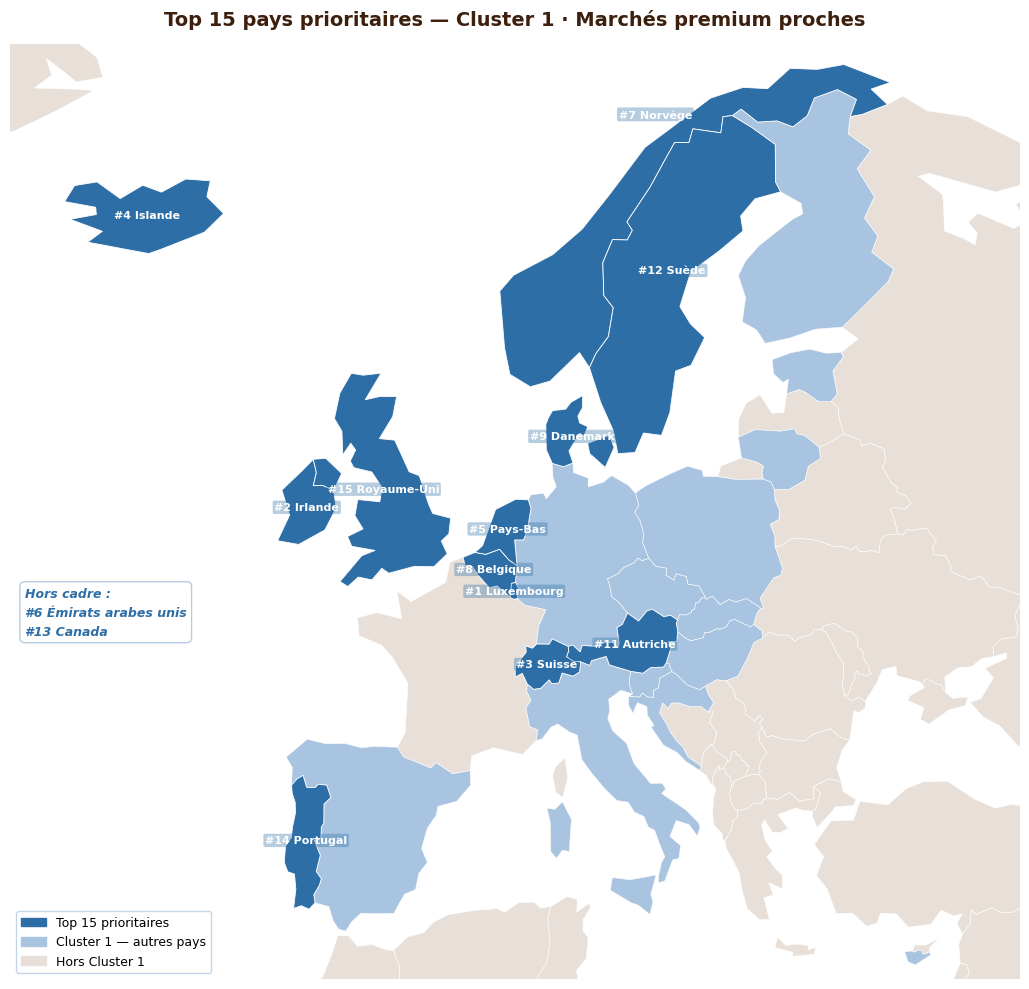

Export OK — 14 pays colorés


In [58]:
# ── Carte Top 15 Cluster 1 — version bleue ──────────────────────────────────

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

dict_pays_iso3 = {
    "Luxembourg":       "LUX",
    "Irlande":          "IRL",
    "Suisse":           "CHE",
    "Islande":          "ISL",
    "Pays-Bas":         "NLD",
    "Émirats arabes unis": "ARE",
    "Norvège":          "NOR",
    "Belgique":         "BEL",
    "Danemark":         "DNK",
    "Malte":            "M10",
    "Autriche":         "AUT",
    "Suède":            "SWE",
    "Canada":           "CAN",
    "Portugal":         "PRT",
    "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord": "GBR",
}

noms_fr = {
    "LUX": "#1 Luxembourg",
    "IRL": "#2 Irlande",
    "CHE": "#3 Suisse",
    "ISL": "#4 Islande",
    "NLD": "#5 Pays-Bas",
    "NOR": "#7 Norvège",
    "BEL": "#8 Belgique",
    "DNK": "#9 Danemark",
    "M10": "#10 Malte",
    "AUT": "#11 Autriche",
    "SWE": "#12 Suède",
    "PRT": "#14 Portugal",
    "GBR": "#15 Royaume-Uni",
}

top15_reset = top15.reset_index(drop=True)
top15_map = []
for i, row in top15_reset.iterrows():
    pays = row['pays']
    iso3 = dict_pays_iso3.get(pays)
    if iso3:
        top15_map.append({'iso3': iso3, 'rang': i+1, 'pays': pays})

top15_df = pd.DataFrame(top15_map)
cluster1_iso3 = df_result[df_result['cluster'] == 1]['iso3'].tolist()

world = gpd.read_file(
    "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
)
world = world.merge(top15_df[['iso3', 'rang']],
                    left_on='ADM0_A3', right_on='iso3', how='left')
world['in_cluster1'] = world['ADM0_A3'].isin(cluster1_iso3)
world['in_top15']    = world['ADM0_A3'].isin(top15_df['iso3'].tolist())

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

world.plot(ax=ax, color='#E8E0D8', edgecolor='white', linewidth=0.4)
world[world['in_cluster1'] & ~world['in_top15']].plot(
    ax=ax, color='#A8C4E0', edgecolor='white', linewidth=0.4)
world[world['in_top15']].plot(
    ax=ax, color='#2E6EA6', edgecolor='white', linewidth=0.6)

ax.set_xlim(-28, 40)
ax.set_ylim(34, 72)

for _, row in world[world['in_top15']].iterrows():
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    iso3 = row['ADM0_A3']
    label = noms_fr.get(iso3)
    if label and -28 <= cx <= 40 and 34 <= cy <= 72:
        ax.annotate(
            label,
            xy=(cx, cy),
            fontsize=8, color='white', fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.15',
                      fc='#2E6EA6', alpha=0.35, lw=0)
        )

ax.text(
    -27, 48.0,
    "Hors cadre :\n#6 Émirats arabes unis\n#13 Canada",
    fontsize=9, color='#2E6EA6', fontstyle='italic',
    fontweight='bold', linespacing=1.6,
    bbox=dict(boxstyle='round,pad=0.4', fc='white',
              alpha=0.85, edgecolor='#A8C4E0')
)

ax.set_title(
    "Top 15 pays prioritaires — Cluster 1 · Marchés premium proches",
    fontsize=14, fontweight='bold', color='#3D1F0D', pad=14
)
ax.axis('off')

leg = [
    mpatches.Patch(color='#2E6EA6', label='Top 15 prioritaires'),
    mpatches.Patch(color='#A8C4E0', label='Cluster 1 — autres pays'),
    mpatches.Patch(color='#E8E0D8', label='Hors Cluster 1'),
]
ax.legend(handles=leg, loc='lower left', fontsize=9,
          framealpha=0.95, edgecolor='#C0D4E8')

plt.tight_layout()
plt.savefig("carte_top15_cluster1.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Export OK — {len(world[world['in_top15']])} pays colorés")

In [59]:
#️⃣ ♦️ Score composite export — Cluster 2

CLUSTER_CIBLE_2 = 2
df_c2 = df_result[df_result['cluster'] == CLUSTER_CIBLE_2].copy()
print(f"Pays dans le cluster cible : {df_c2.shape[0]}")

# Normalisation MinMax sur le Cluster 2
df_c2_norm = df_c2.copy()
df_c2_norm[cols_criteres] = scaler_score.fit_transform(df_c2[cols_criteres])

# Inversion distance_km
df_c2_norm['distance_km'] = 1 - df_c2_norm['distance_km']

# Score composite
df_c2_norm['score_export'] = sum(
    df_c2_norm[col] * poids
    for col, poids in CRITERES.items()
)

# Top 15
top15_c2 = df_c2_norm[['pays', 'score_export']].sort_values(
    'score_export', ascending=False
).head(15).reset_index(drop=True)

top15_c2.index += 1
print("\n=== Top 15 pays prioritaires — Cluster 2 ===\n")
print(top15_c2.to_string())

Pays dans le cluster cible : 40

=== Top 15 pays prioritaires — Cluster 2 ===

                               pays  score_export
1              Saint-Kitts-et-Nevis      0.742980
2                Antigua-et-Barbuda      0.684450
3                              Oman      0.663885
4                          Lettonie      0.655692
5                      Sainte-Lucie      0.625705
6   Saint-Vincent-et-les Grenadines      0.624671
7                           Grenade      0.584165
8                         Dominique      0.566866
9                          Bulgarie      0.553051
10                       Cabo Verde      0.517781
11                Macédoine du Nord      0.514253
12                             Cuba      0.503712
13                           Gambie      0.485837
14                            Gabon      0.485187
15                          Albanie      0.483214


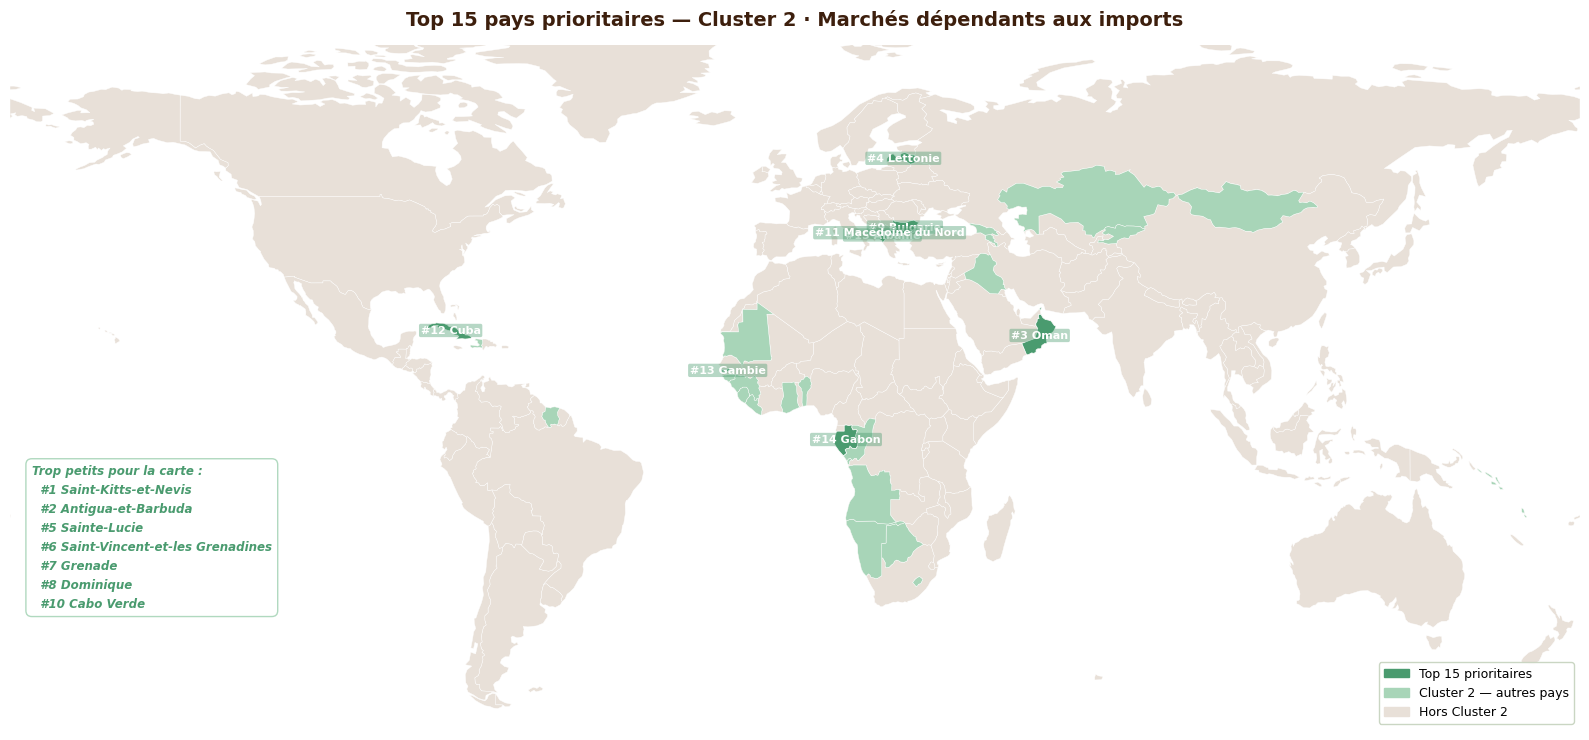

Export OK — 8 pays colorés sur carte


In [60]:
# ── Carte Top 15 Cluster 2 — version finale ─────────────────────────────────

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# Dictionnaire FAO → iso3 Cluster 2
# Petits pays Caraïbes absents du GeoJSON 110m → signalés hors cadre
dict_c2_iso3 = {
    "Saint-Kitts-et-Nevis":           "SKN",  # trop petit → hors cadre
    "Antigua-et-Barbuda":             "ATG",  # trop petit → hors cadre
    "Oman":                           "OMN",
    "Lettonie":                       "LVA",
    "Sainte-Lucie":                   "LCA",  # trop petit → hors cadre
    "Saint-Vincent-et-les Grenadines":"VCT",  # trop petit → hors cadre
    "Grenade":                        "GRD",  # trop petit → hors cadre
    "Dominique":                      "DMA",  # trop petit → hors cadre
    "Bulgarie":                       "BGR",
    "Cabo Verde":                     "CPV",  # trop petit → hors cadre
    "Macédoine du Nord":              "MKD",
    "Cuba":                           "CUB",
    "Gambie":                         "GMB",
    "Gabon":                          "GAB",
    "Albanie":                        "ALB",
}

noms_fr_c2 = {
    "OMN": "#3 Oman",
    "LVA": "#4 Lettonie",
    "BGR": "#9 Bulgarie",
    "MKD": "#11 Macédoine du Nord",
    "CUB": "#12 Cuba",
    "GMB": "#13 Gambie",
    "GAB": "#14 Gabon",
    "ALB": "#15 Albanie",
}

# Pays trop petits pour être visibles sur carte 110m
hors_cadre_c2 = [
    "#1 Saint-Kitts-et-Nevis",
    "#2 Antigua-et-Barbuda",
    "#5 Sainte-Lucie",
    "#6 Saint-Vincent-et-les Grenadines",
    "#7 Grenade",
    "#8 Dominique",
    "#10 Cabo Verde",
]

top15_c2_reset = top15_c2.reset_index(drop=True)
top15_c2_map = []
for i, row in top15_c2_reset.iterrows():
    pays = row['pays']
    iso3 = dict_c2_iso3.get(pays)
    if iso3:
        top15_c2_map.append({'iso3': iso3, 'rang': i+1, 'pays': pays})

top15_c2_df = pd.DataFrame(top15_c2_map)
cluster2_iso3 = df_result[df_result['cluster'] == 2]['iso3'].tolist()

world = gpd.read_file(
    "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
)
world = world.merge(top15_c2_df[['iso3', 'rang']],
                    left_on='ADM0_A3', right_on='iso3', how='left')
world['in_cluster2'] = world['ADM0_A3'].isin(cluster2_iso3)
world['in_top15']    = world['ADM0_A3'].isin(top15_c2_df['iso3'].tolist())

# ── Figure — vue monde entier (cluster 2 dispersé) ──────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(16, 9))

world.plot(ax=ax, color='#E8E0D8', edgecolor='white', linewidth=0.3)
world[world['in_cluster2'] & ~world['in_top15']].plot(
    ax=ax, color='#A8D5B8', edgecolor='white', linewidth=0.3)
world[world['in_top15']].plot(
    ax=ax, color='#4A9B6F', edgecolor='white', linewidth=0.5)

ax.set_xlim(-180, 180)
ax.set_ylim(-60, 80)

# Labels pays visibles
for _, row in world[world['in_top15']].iterrows():
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    iso3 = row['ADM0_A3']
    label = noms_fr_c2.get(iso3)
    if label:
        ax.annotate(
            label,
            xy=(cx, cy),
            fontsize=8, color='white', fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.15',
                      fc='#4A9B6F', alpha=0.4, lw=0)
        )

# Encadré pays trop petits
hors_cadre_txt = "Trop petits pour la carte :\n" + \
                 "  " + "\n  ".join(hors_cadre_c2)
ax.text(
    -175, -35,
    hors_cadre_txt,
    fontsize=8.5, color='#4A9B6F', fontstyle='italic',
    fontweight='bold', linespacing=1.6,
    bbox=dict(boxstyle='round,pad=0.5', fc='white',
              alpha=0.9, edgecolor='#A8D5B8')
)

ax.set_title(
    "Top 15 pays prioritaires — Cluster 2 · Marchés dépendants aux imports",
    fontsize=14, fontweight='bold', color='#3D1F0D', pad=14
)
ax.axis('off')

leg = [
    mpatches.Patch(color='#4A9B6F', label='Top 15 prioritaires'),
    mpatches.Patch(color='#A8D5B8', label='Cluster 2 — autres pays'),
    mpatches.Patch(color='#E8E0D8', label='Hors Cluster 2'),
]
ax.legend(handles=leg, loc='lower right', fontsize=9,
          framealpha=0.95, edgecolor='#C8D4C0')

plt.tight_layout()
plt.savefig("carte_top15_cluster2.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Export OK — {len(world[world['in_top15']])} pays colorés sur carte")

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
E — Export final enrichi
</div>

In [61]:
#️⃣ ♦️ Export final enrichi — CSV

# Construction du fichier final
export_final = df_result[['iso3', 'pays', 'cluster', 'cluster_nom'] + VARIABLES_ACP].copy()

# Ajout des coordonnées ACP F1, F2, F3
export_final['F1'] = X_pca[:, 0].round(4)
export_final['F2'] = X_pca[:, 1].round(4)
export_final['F3'] = X_pca[:, 2].round(4)

# Ajout de la variable illustrative continent
export_final['continent'] = df['continent'].values

# Vérification avant export
print(f"Shape export : {export_final.shape}")
print(f"Colonnes     : {list(export_final.columns)}")
print(f"NaN          : {export_final.isna().sum().sum()}")
print()

# Export CSV
export_final.to_csv("resultats_clustering_final.csv",
                    index=False, encoding="utf-8-sig")

print("Export réussi : resultats_clustering_final.csv")
print(f"Pays exportés : {export_final.shape[0]}")

Shape export : (153, 18)
Colonnes     : ['iso3', 'pays', 'cluster', 'cluster_nom', 'population', 'pib_par_habitant_usd', 'stabilite_politique', 'conso_volaille_kg_hab_an', 'import_qty_tonnes', 'distance_km', 'exportations_tonnes', 'marche_volaille_t', 'taux_dependance_import', 'taux_couverture_locale', 'F1', 'F2', 'F3', 'continent']
NaN          : 0

Export réussi : resultats_clustering_final.csv
Pays exportés : 153


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
F — Conclusion
</div>

<div style="background-color: #fff9c4; padding: 12px; border-left: 5px solid #f9a825; border-radius: 6px;">

**Conclusion — Segmentation des marchés export poulet 2017**

**Méthode :** ACP (5 composantes, 80.75% de variance conservée) + CAH (Ward) 
+ K-means (k=4, silhouette=0.2187, ARI=0.2294)

**Résultats :**

- Cluster 0 — Marchés fragiles (72 pays) : faible pouvoir d'achat, 
  instabilité politique, faible consommation. Cible peu prioritaire.
- Cluster 1 — Marchés premium proches (38 pays) : PIB élevé, stabilité 
  politique, proximité France. **Cible prioritaire export.**
- Cluster 2 — Marchés dépendants aux imports (40 pays) : forte dépendance 
  aux imports, autosuffisance faible. Cible secondaire intéressante.
- Cluster 3 — Géants inaccessibles (3 pays : Brésil, Chine continentale, 
  États-Unis d'Amérique) : volumes extrêmes, autosuffisants. 
  Hors cible PME française.

**Cible prioritaire export — Cluster 1 (Marchés premium proches) :**
PIB élevé, stabilité politique, proximité géographique avec la France — 
profil idéal pour un premier développement à l'export.

**Top 5 prioritaires Cluster 1 :** Luxembourg, Irlande, Suisse, Islande, Pays-Bas

**Limites :** Le score mesure l'attractivité structurelle — le volume de marché 
doit être vérifié séparément avant toute décision commerciale. 
ARI faible (0.2294) indique une divergence forte entre CAH et K-means, 
documentée et justifiée.

</div>